# Before we start: three tabs

A warm-up. There is nothing to run on this page — these are three views of the machine we
are about to take apart, and together they take about five minutes.

**1. [LLM Visualization](https://bbycroft.net/llm)** — a GPT laid out in 3D, every matrix
drawn at its real relative size. Pick a token and follow it all the way from the embedding
to the logit. Everything written by hand today sits somewhere in that diagram.

**2. [Transformer Explainer](https://poloclub.github.io/transformer-explainer/)** — a real
GPT-2 small, 124M parameters, running in your browser through ONNX. Type a phrase, then
move the temperature and top-p sliders and watch the distribution tighten and spread out.
The decoder is a separate function sitting after the model, and this shows it before we
write a line of code.

**3. [LLM Architecture Gallery](https://sebastianraschka.com/llm-architecture-gallery/)** —
block diagrams of about 95 models in one style and one scale, from GPT-2 to DeepSeek-V4.
Scroll through it. They look alike in the middle and differ at the edges; by the end of the
seminar you will know which edges, and why those.

---

# 02 — the current stack, in code

**For blocks 0–3 of lecture 2.**

We write the moving parts of a 2026 transformer ourselves, in the same conventions
[nanochat](https://github.com/karpathy/nanochat) uses — the repository we read in the first
half of this block. Its `gpt.py` opens with a list of what makes it current, and that list
is our plan:

> rotary embeddings (and no positional embeddings) · QK norm · untied weights for token
> embedding and lm_head · relu^2 activation in MLP · norm after token embedding · no
> learnable params in rmsnorm · no bias in linear layers · Group-Query Attention (GQA)

Two things sit outside that list and we add them here: **MoE**, which nanochat does not
have and the frontier does, and **SwiGLU**, which the frontier prefers where nanochat picked
`relu²`. Both are one config flag away.

There is no GPT-2 baseline in this file on purpose. Reading one stack and remembering it
beats reading two and remembering the difference between them.

Runtime ~3 minutes on CPU. Dependencies: `torch`. Everything runs on CPU.

In [1]:
from __future__ import annotations

import math
import sys
import time
from dataclasses import dataclass, replace

import torch
import torch.nn as nn
import torch.nn.functional as F

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8", errors="replace")
torch.manual_seed(0)

## The config: every knob is one architectural decision

In [2]:
@dataclass
class Cfg:
    vocab_size: int = 32768           # nanochat's own tokenizer size
    block_size: int = 2048
    n_layer: int = 12
    n_head: int = 6                   # query heads
    n_kv_head: int = 6                # = n_head → MHA; < n_head → GQA
    n_embd: int = 768
    d_ff: int | None = None           # None → derived from act
    act: str = "relu2"                # "relu2" (nanochat) | "swiglu" (the frontier)
    rope_theta: float = 100000.0      # nanochat's base; Llama-3 uses 500k, Qwen3 1M
    tie_embeddings: bool = False      # nanochat unties them; small models still tie
    # --- MoE: nanochat has none, the frontier is built on it
    n_experts: int = 0                # 0 → dense FFN
    n_experts_active: int = 2
    n_shared_experts: int = 0
    d_ff_expert: int | None = None    # None → d_ff // 4: "fine-grained", narrow experts

    def __post_init__(self):
        if self.d_ff is None:
            # with GLU there are three matrices instead of two, so d_ff is squeezed to ~8/3·d
            # in order to keep the same ~8d² parameters in the FFN
            self.d_ff = int(8 / 3 * self.n_embd) if self.act == "swiglu" else 4 * self.n_embd
            self.d_ff = (self.d_ff + 63) // 64 * 64      # round up for the tensor cores


PRESETS = {
    # the file we just read, at its default size
    "nanochat": Cfg(),
    # the frontier dense stack: same skeleton, SwiGLU instead of relu², GQA 3:1
    "llama3": Cfg(vocab_size=128256, n_kv_head=2, act="swiglu", rope_theta=500000.0),
    "qwen3": Cfg(vocab_size=151936, n_kv_head=2, act="swiglu", rope_theta=1000000.0),
    # the sparse variant: the same skeleton, but the FFN is replaced by MoE
    "moe": Cfg(vocab_size=128256, n_kv_head=2, act="swiglu",
               n_experts=16, n_experts_active=2, n_shared_experts=1),
}

## 1. The norm, and why it has no parameters

`F.rms_norm` divides by the root mean square over the last dimension. nanochat applies it
with **no learnable gain at all** — so every norm in the model costs exactly zero
parameters. That is worth pausing on: the thing that decides whether a large run converges
is free in the parameter budget.

In [3]:
def norm(x):
    return F.rms_norm(x, (x.size(-1),))

## 2. Positions: RoPE, and the convention that breaks weight ports

The position stops being a summand at the input and becomes a rotation inside attention.
`V` is not rotated — only `Q` and `K`.

**Which coordinates get paired matters.** The RoPE paper pairs neighbours (0,1), (2,3), …
nanochat and Hugging Face split the vector in half and pair `i` with `i + d/2`. The two are
a permutation apart and mathematically equivalent — but weights ported between them without
the permutation silently produce garbage. We follow nanochat: halves.

In [4]:
def rope_cache(T, dh, theta, device):
    freqs = theta ** (-torch.arange(0, dh, 2, device=device).float() / dh)
    ang = torch.arange(T, device=device).float()[:, None] * freqs[None, :]
    return ang.cos(), ang.sin()


def apply_rope(x, cos, sin):
    # x: (B, h, T, dh). Halves convention: pair coordinate i with coordinate i + dh/2.
    d = x.shape[-1] // 2
    x1, x2 = x[..., :d], x[..., d:]
    c, s = cos[None, None], sin[None, None]
    return torch.cat([x1 * c - x2 * s, x1 * s + x2 * c], dim=-1)

## 3. Attention: GQA and QK-norm

Two things here beyond plain causal attention.

**GQA** — the KV heads are fewer than the query heads, and each one serves a group. This is
the single knob that sets the size of the KV cache, and block 4 is what that costs.

**QK-norm** — the attention logit is `q·k/√d`, bilinear in the weights: scale `W_q` and `W_k`
by `c` and the logits grow by `c²`. Nothing in the loss penalizes that, so at scale the
logits drift into the tens, softmax saturates and the run dies. Normalizing `q` and `k`
removes the degree of freedom. Note the order: nanochat normalizes **after** the rotation,
Qwen3 and OLMo 2 before it. A rotation preserves the norm, so both give the same bound.

In [5]:
class Attention(nn.Module):
    def __init__(self, cfg: Cfg):
        super().__init__()
        assert cfg.n_head % cfg.n_kv_head == 0
        self.cfg = cfg
        self.dh = cfg.n_embd // cfg.n_head
        self.q = nn.Linear(cfg.n_embd, cfg.n_head * self.dh, bias=False)
        self.k = nn.Linear(cfg.n_embd, cfg.n_kv_head * self.dh, bias=False)
        self.v = nn.Linear(cfg.n_embd, cfg.n_kv_head * self.dh, bias=False)
        self.o = nn.Linear(cfg.n_head * self.dh, cfg.n_embd, bias=False)

    def forward(self, x, rope):
        B, T, C = x.shape
        c = self.cfg
        q = self.q(x).view(B, T, c.n_head, self.dh).transpose(1, 2)
        k = self.k(x).view(B, T, c.n_kv_head, self.dh).transpose(1, 2)
        v = self.v(x).view(B, T, c.n_kv_head, self.dh).transpose(1, 2)
        q, k = apply_rope(q, *rope), apply_rope(k, *rope)
        q, k = norm(q), norm(k)          # QK-norm, per head: the norm is over dh, not over C
        if c.n_kv_head != c.n_head:
            rep = c.n_head // c.n_kv_head
            k, v = k.repeat_interleave(rep, 1), v.repeat_interleave(rep, 1)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        return self.o(y.transpose(1, 2).reshape(B, T, C))

## 4. The FFN: relu² or SwiGLU

nanochat uses `relu(x)²` with a plain `4d` hidden layer — two matrices, no gate. The
frontier (Llama, Qwen, DeepSeek) uses SwiGLU: three matrices, and `d_ff` squeezed to `8/3·d`
so the parameter count comes out the same. Both are here behind one flag, because the
showcase in block 6 has rows of each kind and the disagreement is real.

In [6]:
class MLP(nn.Module):
    def __init__(self, cfg: Cfg, d_ff: int | None = None):
        super().__init__()
        self.act = cfg.act
        d, f = cfg.n_embd, d_ff or cfg.d_ff
        if cfg.act == "swiglu":
            self.gate = nn.Linear(d, f, bias=False)      # ← the third matrix, the "gate"
        self.up = nn.Linear(d, f, bias=False)
        self.down = nn.Linear(f, d, bias=False)

    def forward(self, x):
        if self.act == "swiglu":
            # SiLU(gate) * up — an elementwise product, hence "gated"
            return self.down(F.silu(self.gate(x)) * self.up(x))
        return self.down(F.relu(self.up(x)).square())

## 5. MoE: the part nanochat does not have

The router picks the top-k experts for EVERY TOKEN (not for the sequence).
The shared expert (the DeepSeek line) is computed always — the common knowledge drains
into it, so that the routed experts are free to specialize. Its collapse is block 3.

In [7]:
class MoE(nn.Module):
    def __init__(self, cfg: Cfg):
        super().__init__()
        self.cfg = cfg
        # fine-grained (the DeepSeek line): the experts are narrow, but there are many of them.
        # That way the "resolution" of specialization is higher at the same active compute.
        d_ff_expert = cfg.d_ff_expert or max(64, cfg.d_ff // 4)
        self.router = nn.Linear(cfg.n_embd, cfg.n_experts, bias=False)
        self.experts = nn.ModuleList([MLP(cfg, d_ff_expert) for _ in range(cfg.n_experts)])
        self.shared = nn.ModuleList([MLP(cfg, d_ff_expert) for _ in range(cfg.n_shared_experts)])
        self.last_load: torch.Tensor | None = None

    def forward(self, x):
        B, T, C = x.shape
        flat = x.view(-1, C)
        logits = self.router(flat)
        w, idx = logits.softmax(-1).topk(self.cfg.n_experts_active, dim=-1)
        w = w / w.sum(-1, keepdim=True)
        out = torch.zeros_like(flat)
        for e, expert in enumerate(self.experts):
            hit = (idx == e)
            if not hit.any():
                continue
            tok = hit.any(-1).nonzero(as_tuple=True)[0]          # which tokens landed here
            coef = (w * hit).sum(-1)[tok, None]
            out.index_add_(0, tok, expert(flat[tok]) * coef)
        for sh in self.shared:
            out = out + sh(flat)
        self.last_load = torch.bincount(idx.flatten(), minlength=self.cfg.n_experts).float()
        return out.view(B, T, C)

## 6. The block: two lines, and the whole residual stream

The norm sits inside the branch, never on the stream. That is what keeps
`x_L = x_0 + Σ(branch outputs)` an exact identity — and block 5 decomposes a real logit
along it.

In [8]:
class Block(nn.Module):
    def __init__(self, cfg: Cfg):
        super().__init__()
        self.attn = Attention(cfg)
        self.ffn = MoE(cfg) if cfg.n_experts else MLP(cfg)

    def forward(self, x, rope):
        x = x + self.attn(norm(x), rope)
        return x + self.ffn(norm(x))

In [9]:
class GPT(nn.Module):
    def __init__(self, cfg: Cfg):
        super().__init__()
        self.cfg = cfg
        self.wte = nn.Embedding(cfg.vocab_size, cfg.n_embd)
        self.blocks = nn.ModuleList([Block(cfg) for _ in range(cfg.n_layer)])
        self.head = nn.Linear(cfg.n_embd, cfg.vocab_size, bias=False)
        if cfg.tie_embeddings:
            self.head.weight = self.wte.weight       # weight tying: saves V·d parameters
        self.apply(self._init)
        # damp the output projections so the residual stream does not grow with depth.
        # nanochat goes further and initializes them at exactly zero — every block starts
        # as the identity and has to earn its contribution.
        for n, p in self.named_parameters():
            if n.endswith(("o.weight", "down.weight")):
                nn.init.normal_(p, 0.0, 0.02 / math.sqrt(2 * cfg.n_layer))

    @staticmethod
    def _init(m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, 0.0, 0.02)
        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, 0.0, 0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        c = self.cfg
        x = norm(self.wte(idx))          # "norm after token embedding", straight from the list
        rope = rope_cache(T, c.n_embd // c.n_head, c.rope_theta, idx.device)
        for b in self.blocks:
            x = b(x, rope)
        logits = self.head(norm(x))
        if targets is None:
            return logits, None
        return logits, F.cross_entropy(logits.view(-1, c.vocab_size), targets.reshape(-1))

    # --- the parameter budget, broken down by purpose
    def budget(self) -> dict[str, int]:
        c = self.cfg
        g = lambda pred: sum(p.numel() for n, p in self.named_parameters() if pred(n))
        emb = self.wte.weight.numel()
        head = 0 if c.tie_embeddings else self.head.weight.numel()
        attn = g(lambda n: ".attn." in n)
        ffn = g(lambda n: ".ffn." in n)
        return {"embedding": emb, "attention": attn, "ffn": ffn, "lm_head": head,
                "total": emb + head + attn + ffn}

    def active_params(self) -> int:
        """How many parameters really take part in the forward pass of one token (for MoE)."""
        b = self.budget()
        if not self.cfg.n_experts:
            return b["total"]
        per_expert = sum(p.numel() for p in self.blocks[0].ffn.experts[0].parameters())
        shared = sum(p.numel() for p in self.blocks[0].ffn.shared.parameters())
        router = sum(p.numel() for p in self.blocks[0].ffn.router.parameters())
        act_ffn = self.cfg.n_layer * (self.cfg.n_experts_active * per_expert + shared + router)
        return b["total"] - b["ffn"] + act_ffn

## 7. What the stack costs

Four configurations of the same skeleton. There is no `norm` column in this table, and that
is the point: with a parameter-free RMSNorm every norm in the model — including the two
QK-norms per layer — costs zero. The vocabulary, on the other hand, is loud: it is the only
column that changes when nothing about the architecture does.

In [10]:
def report(name: str, cfg: Cfg, bench=True) -> dict:
    m = GPT(cfg)
    b = m.budget()
    act = m.active_params()
    x = torch.randint(0, cfg.vocab_size, (2, 128))
    dt = float("nan")
    if bench:
        _, loss = m(x, x)
        loss.backward()
        t0 = time.perf_counter()
        for _ in range(3):
            m.zero_grad(set_to_none=True)
            _, loss = m(x, x)
            loss.backward()
        dt = (time.perf_counter() - t0) / 3 * 1e3
    return dict(name=name, total=b["total"], active=act, emb=b["embedding"],
                head=b["lm_head"], attn=b["attention"], ffn=b["ffn"], ms=dt)


def print_table(rows: list[dict]) -> None:
    print(f"{'configuration':<14}{'total':>10}{'active':>10}{'emb':>9}{'lm_head':>9}"
          f"{'attn':>9}{'ffn':>9}{'step, ms':>10}")
    print("-" * 80)
    for r in rows:
        M = lambda v: f"{v / 1e6:.1f}M"
        print(f"{r['name']:<14}{M(r['total']):>10}{M(r['active']):>10}{M(r['emb']):>9}"
              f"{M(r['head']):>9}{M(r['attn']):>9}{M(r['ffn']):>9}{r['ms']:>10.0f}")

In [11]:
print("The same skeleton under four configurations\n")
rows = [report(k, v) for k, v in PRESETS.items()]
print_table(rows)

nc, moe = rows[0], rows[-1]
print(f"""
What to read in the table:
  • the norms are absent from it because they hold no parameters at all — and the two
    QK-norms per layer, the thing that keeps large runs from diverging, are part of that zero;
  • embedding + lm_head eats {100 * (nc['emb'] + nc['head']) / nc['total']:.0f}% of the nanochat configuration
    and {100 * (moe['emb'] + moe['head']) / moe['total']:.0f}% of the MoE one while the architecture does not change at all —
    the tokenizer is a line item in the budget, and block 4 makes that the whole story;
  • relu² against SwiGLU is a wash in parameters: the frontier squeezes d_ff to 8/3·d exactly
    so that the third matrix comes for free. It is a convention, not a coincidence;
  • in the MoE row "total" and "active" come apart: {moe['total'] / 1e6:.0f}M held against {moe['active'] / 1e6:.0f}M computed
    per token. That gap is what DeepSeek (671B / 37B) and Kimi K2 (1T / 32B) scale up.

⚠ The "step, ms" column on CPU must NOT be read as a comparison of architectures. It is here
  only as an order of magnitude and as a check that the model assembles and computes a
  gradient at all.
""")

The same skeleton under four configurations

configuration      total    active      emb  lm_head     attn      ffn  step, ms
--------------------------------------------------------------------------------
nanochat          135.3M    135.3M    25.2M    25.2M    28.3M    56.6M      1076
llama3            272.5M    272.5M    98.5M    98.5M    18.9M    56.6M      1479
qwen3             308.9M    308.9M   116.7M   116.7M    18.9M    56.6M      1601
moe               456.7M    258.5M    98.5M    98.5M    18.9M   240.8M      1983

What to read in the table:
  • the norms are absent from it because they hold no parameters at all — and the two
    QK-norms per layer, the thing that keeps large runs from diverging, are part of that zero;
  • embedding + lm_head eats 37% of the nanochat configuration
    and 43% of the MoE one while the architecture does not change at all —
    the tokenizer is a line item in the budget, and block 4 makes that the whole story;
  • relu² against SwiGLU is a wash

## 8. A check that the whole construction really does learn

Without this step you get "we drew an architecture and went home". We run all four presets
on a toy task with a repeating structure: if the loss went noticeably below the chance
level, then the forward and the backward pass are assembled correctly.

In [12]:
print("A check that this whole construction really does learn\n")
for name in PRESETS:
    cfg = replace(PRESETS[name], vocab_size=256, n_layer=4, n_embd=128,
                  n_head=4, n_kv_head=2, block_size=64, d_ff=None)
    torch.manual_seed(0)
    m = GPT(cfg)
    opt = torch.optim.AdamW(m.parameters(), lr=3e-3, weight_decay=0.1, betas=(0.9, 0.95))
    data = torch.randint(0, 256, (32, 33))
    data = data.repeat(1, 2)[:, :65]      # a repeating structure — it can be learned
    for i in range(200):
        _, loss = m(data[:, :-1], data[:, 1:])
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
        opt.step()
    print(f"  {name:<10} loss after 200 steps: {loss.item():.3f} "
          f"(chance level {math.log(256):.2f})")

A check that this whole construction really does learn

  nanochat   loss after 200 steps: 0.001 (chance level 5.55)
  llama3     loss after 200 steps: 0.003 (chance level 5.55)
  qwen3      loss after 200 steps: 0.003 (chance level 5.55)
  moe        loss after 200 steps: 0.012 (chance level 5.55)


## 9. Where nanochat goes further than the frontier

Reading `gpt.py` you will also meet things that are **not** in Llama, Qwen or DeepSeek, and
it is worth knowing which is which before you carry them into your own model. They come from
the modded-nanogpt speedrun lineage, where the target is wall-clock time to a loss:

* **value embeddings** (ResFormer) on alternating layers, mixed in through a sigmoid gate;
* **smear** — a learned blend of the previous token's embedding into the current one;
* **backout** — a cached mid-layer residual subtracted before the final norm;
* **`resid_lambdas` / `x0_lambdas`** — per-layer learnable scalars on the stream, and a
  learned path that blends the original embedding back in at every layer;
* **`q *= 1.2; k *= 1.2`** after QK-norm, to sharpen attention back up. The source marks it
  `TODO think through better` — which is the honest status of the trick.

The sliding-window pattern (`"SSSL"`: three short layers then one full-context one) is the
opposite case — it is not exotic at all, and block 6 shows the same 3:1 shape in Qwen3.6,
Qwen3.8 and Kimi K3.

---

# 03 — The sampling lab: what the decoder does to the distribution

**Lecture 2, block 0** (generation: greedy / temperature / top-k / top-p).

The model emits a distribution over the vocabulary. The decoder is a **separate function**
that turns it into a token, and it is not part of the model.
Here we:

1. look at the shape of a real distribution and at what each knob does to it;
2. train a small char-level model and **read the generated text**:
   greedy loops, a high temperature disintegrates into noise;
3. work through min-p, and where the decoder settings actually come from today.

Runtime ~2.5 minutes on CPU, most of it the training and the generations.
Dependencies: `torch`, `matplotlib`. The first run downloads ~1 MB of tinyshakespeare
(with no network — the built-in fallback text kicks in).

In [13]:
from __future__ import annotations

import math
import sys
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8", errors="replace")

OUT = Path("out")
OUT.mkdir(exist_ok=True)
torch.manual_seed(1337)

## 1. Four knobs on one and the same distribution

Formally:
* **temperature** `T`: `logits / T` — stretches or squeezes the differences BEFORE softmax;
* **top-k**: keep the k most probable ones;
* **top-p (nucleus)**: keep the shortest prefix whose total mass is ≥ p;
* **min-p**: keep everything whose probability is ≥ `p · max(prob)` — a **relative** threshold.

In [14]:
def apply_temperature(logits, t):
    return logits / max(t, 1e-6)


def top_k_filter(logits, k):
    if k is None or k <= 0:
        return logits
    v, _ = torch.topk(logits, min(k, logits.size(-1)))
    return logits.masked_fill(logits < v[..., -1:], -float("inf"))


def top_p_filter(logits, p):
    if p is None or p >= 1.0:
        return logits
    s, idx = logits.sort(descending=True, dim=-1)
    cum = s.softmax(-1).cumsum(-1)
    drop = cum - s.softmax(-1) >= p       # keep the shortest prefix with mass ≥ p
    s = s.masked_fill(drop, -float("inf"))
    return torch.empty_like(logits).scatter_(-1, idx, s)


def min_p_filter(logits, p):
    if p is None or p <= 0:
        return logits
    probs = logits.softmax(-1)
    return logits.masked_fill(probs < p * probs.max(-1, keepdim=True).values, -float("inf"))


def survivors(logits) -> int:
    return int(torch.isfinite(logits).sum())


# two typical cases: the model is confident and the model is not
V = 200
rank = torch.arange(1, V + 1).float()
PEAKED = torch.log(rank ** -2.2); PEAKED -= PEAKED.logsumexp(-1)      # almost one-hot
FLAT = torch.log(rank ** -0.6); FLAT -= FLAT.logsumexp(-1)            # smeared out

print(f"{'distribution':<16}{'knob':<18}{'surviving tokens':>16}{'entropy':>11}{'max p':>9}")
print("-" * 72)
for name, base in [("confident", PEAKED), ("uncertain", FLAT)]:
    for tag, fn in [
        ("original", lambda x: x),
        ("T=0.7", lambda x: apply_temperature(x, 0.7)),
        ("T=1.5", lambda x: apply_temperature(x, 1.5)),
        ("top-k=20", lambda x: top_k_filter(x, 20)),
        ("top-p=0.95", lambda x: top_p_filter(x, 0.95)),
        ("min-p=0.05", lambda x: min_p_filter(x, 0.05)),
        ("k=20 + p=0.95", lambda x: top_p_filter(top_k_filter(x, 20), 0.95)),
    ]:
        z = fn(base.clone())
        p = z.softmax(-1)
        ent = -(p * (p + 1e-20).log()).sum()
        print(f"{name:<16}{tag:<18}{survivors(z):>16}{ent:>11.2f}{p.max():>9.3f}")
    print()

print("""
Read the "surviving tokens" column:
  • top-k=20 keeps exactly 20 in BOTH cases — a fixed k never looks at the shape of the
    distribution. That is Holtzman's objection (2019), and it is correct;
  • top-p adapts: a handful on a confident distribution, 179 on a smeared one. That is its
    point and also its problem — nothing bounds that number from above;
  • min-p adapts on a different principle: the threshold is relative to the maximum. On a
    CONFIDENT distribution that holds up at a high temperature where top-p does not (at T=1.5:
    7 survivors against 63). On a smeared one it saves nothing — at T=1.5 all 200 tokens
    clear 0.05·max;
  • the last row is what actually ships. The filters are composed, not chosen, and each one
    binds in a different regime: on a confident distribution the limit comes from top-p and
    top-k never fires; on a smeared one top-k is what turns 179 candidates into 19, because it
    is the only one of the three with an upper bound at all.
""")

distribution    knob              surviving tokens    entropy    max p
------------------------------------------------------------------------
confident       original                       200       1.32    0.672
confident       T=0.7                          200       0.61    0.850
confident       T=1.5                          200       2.76    0.389
confident       top-k=20                        20       1.21    0.681
confident       top-p=0.95                       7       1.00    0.706
confident       min-p=0.05                       3       0.69    0.765
confident       k=20 + p=0.95                    6       0.96    0.713

uncertain       original                       200       4.99    0.053
uncertain       T=0.7                          200       4.52    0.118
uncertain       T=1.5                          200       5.19    0.026
uncertain       top-k=20                        20       2.84    0.156
uncertain       top-p=0.95                     179       4.88    0.056
unc

## 2. Where the decoder settings come from

Until transformers 5 the library itself set `top_k=50`: whoever passed `do_sample=True` and
touched nothing else sampled through a top-k filter they never chose. In 5.x every sampling
field defaults to `None` and no filter is added until someone asks for one — and that someone
is the model's own `generation_config.json`. vLLM starts from the same blank state
(`top_k=0`, `top_p=1.0`, `T=1.0`) and then reads that same file out of the model repo.

So "what is the default sampler" now has a per-model answer
(`generation_config.json`, fetched 14-09-2026):

| model | T | top_k | top_p |
|---|---|---|---|
| Qwen3-8B, Qwen3-Next-80B-A3B-Thinking | 0.6 | **20** | 0.95 |
| Qwen3-Next-80B-A3B-Instruct, Qwen3-235B-A22B-2507 | 0.7 | **20** | 0.8 |
| Gemma 3 4B it | 1.0 | **64** | 0.95 |
| Llama 3.1 8B Instruct | 0.6 | — | 0.9 |
| DeepSeek-R1, DeepSeek-V3.2-Exp | 0.6 | — | 0.95 |
| GLM-4.6 | 1.0 | — | — |
| Kimi-K2-Instruct, gpt-oss-20b, phi-4, OLMo 2 | — | — | — |

The split runs by vendor, not by year: the whole Qwen line ships top-k, the DeepSeek and
Llama lines never have. `min_p` appears in none of these files — it is a knob the serving
stacks offer and the model cards do not ask for.

## 3. The picture: what each knob cuts off

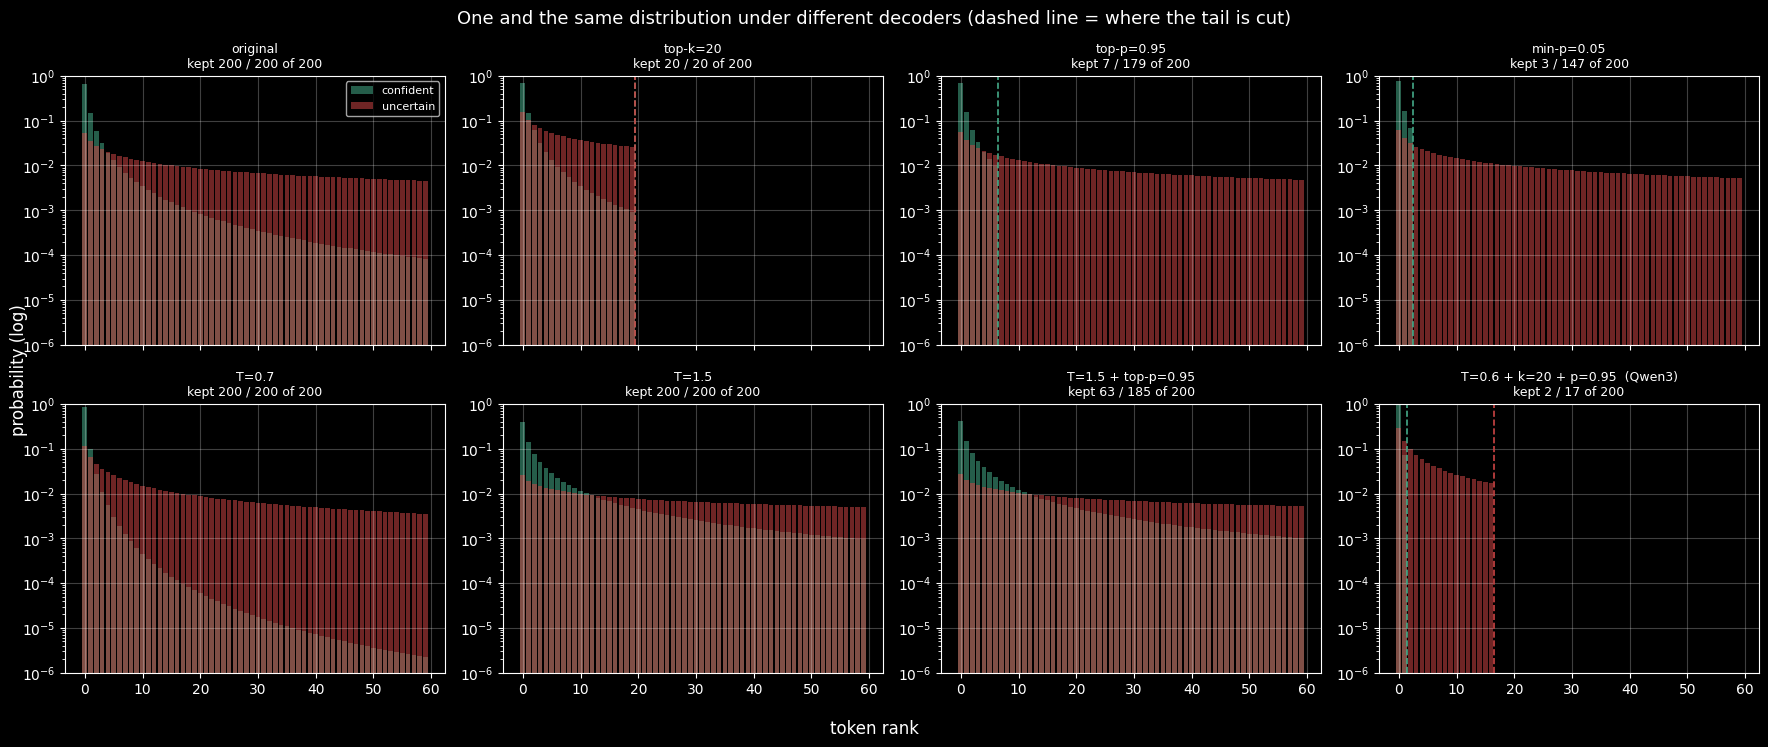

→ out\03_sampling_filters.png


In [15]:
# Top row: the three truncation filters against the unfiltered distribution.
# Bottom row: temperature, and what it does once a filter is composed with it.
fig, ax = plt.subplots(2, 4, figsize=(18, 7.5), sharex=True)
CONFIGS = [("original", lambda x: x),
           ("top-k=20", lambda x: top_k_filter(x, 20)),
           ("top-p=0.95", lambda x: top_p_filter(x, 0.95)),
           ("min-p=0.05", lambda x: min_p_filter(x, 0.05)),
           ("T=0.7", lambda x: apply_temperature(x, 0.7)),
           ("T=1.5", lambda x: apply_temperature(x, 1.5)),
           ("T=1.5 + top-p=0.95",
            lambda x: top_p_filter(apply_temperature(x, 1.5), 0.95)),
           ("T=0.6 + k=20 + p=0.95  (Qwen3)",
            lambda x: top_p_filter(top_k_filter(apply_temperature(x, 0.6), 20), 0.95))]
for axi, (tag, fn) in zip(ax.ravel(), CONFIGS):
    kept = []
    for base, c, lbl in [(PEAKED, "#4a8", "confident"), (FLAT, "#c44", "uncertain")]:
        z = fn(base.clone())
        kept.append(survivors(z))
        axi.bar(range(60), z.softmax(-1)[:60].numpy(), color=c, alpha=.55, label=lbl)
        if kept[-1] < 60:                  # where the tail is cut, and by how much
            axi.axvline(kept[-1] - .5, color=c, ls="--", lw=1.2)
    axi.set_title(f"{tag}\nkept {kept[0]} / {kept[1]} of 200", fontsize=9)
    axi.set_yscale("log"); axi.set_ylim(1e-6, 1); axi.grid(alpha=.25)
ax[0, 0].legend(fontsize=8)
fig.supxlabel("token rank"); fig.supylabel("probability (log)")
fig.suptitle("One and the same distribution under different decoders "
             "(dashed line = where the tail is cut)", fontsize=13)
fig.tight_layout(); fig.savefig(OUT / "03_sampling_filters.png", dpi=140)
plt.show()
print(f"→ {OUT / '03_sampling_filters.png'}")

## 4. Train a char-level model so that we can read real text

A small character-level model. The quality is not what matters to us — what matters is that
the distributions are real and the text can be read with the eyes.

In [16]:
FALLBACK = ("To be, or not to be, that is the question: whether tis nobler in the mind "
            "to suffer the slings and arrows of outrageous fortune. " * 200)
data_path = OUT / "tinyshakespeare.txt"
if not data_path.exists():
    try:
        url = ("https://raw.githubusercontent.com/karpathy/char-rnn/master/data/"
               "tinyshakespeare/input.txt")
        with urllib.request.urlopen(url, timeout=30) as r:
            data_path.write_text(r.read().decode("utf-8"), encoding="utf-8")
        print(f"downloaded tinyshakespeare → {data_path}")
    except Exception as e:
        print(f"no network ({type(e).__name__}), falling back to the built-in text")
        data_path.write_text(FALLBACK, encoding="utf-8")

text = data_path.read_text(encoding="utf-8")
chars = sorted(set(text))
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}
data = torch.tensor([stoi[c] for c in text], dtype=torch.long)
NV, BLOCK = len(chars), 96
print(f"corpus: {len(text)} characters, alphabet {NV}")


class CharGPT(nn.Module):
    def __init__(self, d=128, n_layer=4, n_head=4):
        super().__init__()
        self.tok, self.pos = nn.Embedding(NV, d), nn.Embedding(BLOCK, d)
        self.h = nn.ModuleList([nn.ModuleDict(dict(
            n1=nn.LayerNorm(d), n2=nn.LayerNorm(d),
            qkv=nn.Linear(d, 3 * d, bias=False), o=nn.Linear(d, d, bias=False),
            up=nn.Linear(d, 4 * d), down=nn.Linear(4 * d, d))) for _ in range(n_layer)])
        self.nf, self.head = nn.LayerNorm(d), nn.Linear(d, NV, bias=False)
        self.nh, self.d = n_head, d

    def forward(self, idx):
        B, T = idx.shape
        x = self.tok(idx) + self.pos(torch.arange(T, device=idx.device))
        for b in self.h:
            q, k, v = b["qkv"](b["n1"](x)).view(B, T, 3, self.nh, self.d // self.nh) \
                .permute(2, 0, 3, 1, 4)
            a = F.scaled_dot_product_attention(q, k, v, is_causal=True)
            x = x + b["o"](a.transpose(1, 2).reshape(B, T, self.d))
            x = x + b["down"](F.gelu(b["up"](b["n2"](x))))
        return self.head(self.nf(x))


model = CharGPT()
opt = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=0.1, betas=(0.9, 0.95))
STEPS = 900
print(f"training {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M parameters, "
      f"{STEPS} steps...")
for step in range(STEPS):
    ix = torch.randint(len(data) - BLOCK - 1, (32,))
    xb = torch.stack([data[i:i + BLOCK] for i in ix])
    yb = torch.stack([data[i + 1:i + 1 + BLOCK] for i in ix])
    loss = F.cross_entropy(model(xb).view(-1, NV), yb.reshape(-1))
    opt.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step()
    if step % 300 == 0:
        print(f"  step {step:>5}  loss {loss.item():.3f}")
print(f"  done, loss {loss.item():.3f}\n")

corpus: 1115394 characters, alphabet 65
training 0.82M parameters, 900 steps...
  step     0  loss 4.406
  step   300  loss 1.956
  step   600  loss 1.691
  done, loss 1.571



## 5. Reading what comes out

This is what it was all for: one and the same model, different decoders, different text.

In [17]:
@torch.no_grad()
def generate(prompt: str, n=280, temp=1.0, top_k=None, top_p=None, min_p=None, greedy=False):
    idx = torch.tensor([[stoi.get(c, 0) for c in prompt]])
    ents = []
    for _ in range(n):
        logits = model(idx[:, -BLOCK:])[:, -1]
        p_full = logits.softmax(-1)
        ents.append(float(-(p_full * (p_full + 1e-20).log()).sum()))
        if greedy:
            nxt = logits.argmax(-1, keepdim=True)
        else:
            z = apply_temperature(logits, temp)
            z = min_p_filter(top_p_filter(top_k_filter(z, top_k), top_p), min_p)
            nxt = torch.multinomial(z.softmax(-1), 1)
        idx = torch.cat([idx, nxt], 1)
    return "".join(itos[int(i)] for i in idx[0]), ents


PROMPT = "KING RICHARD" if "KING" in text else text[:12]
RECIPES = [
    ("greedy (argmax)", dict(greedy=True)),
    ("T=1.0, no filters", dict(temp=1.0)),
    ("T=0.8 + top-k=40", dict(temp=0.8, top_k=40)),
    ("T=0.8 + top-p=0.9", dict(temp=0.8, top_p=0.9)),
    ("T=0.6 + k=20 + p=0.95 (the Qwen3 card)",
     dict(temp=0.6, top_k=20, top_p=0.95)),
    ("T=1.5 + min-p=0.05", dict(temp=1.5, min_p=0.05)),
    ("T=2.0, no filters", dict(temp=2.0)),
]
for name, kw in RECIPES:
    torch.manual_seed(0)
    out, _ = generate(PROMPT, **kw)
    body = out[len(PROMPT):].replace("\n", " ⏎ ")
    print(f"── {name} " + "─" * (58 - len(name)))
    print(f"   {body[:230]}\n")

print("""
What this says:
  • greedy — deterministic, and it almost always slides into repetition. This is not a bug in
    the model: the most probable token leads to a state where it is again the most probable.
    The phenomenon is called neural text degeneration (Holtzman et al., 2019);
  • T=2.0 with no filters — the opposite failure: the model draws tokens from the tail,
    where all the garbage lives;
  • T=0.8 + top-k/top-p — the working range;
  • T=1.5 + min-p=0.05 — an illustration of the claim min-p was invented for:
    a high temperature PLUS a relative threshold gives diversity without disintegration.
""")

── greedy (argmax) ───────────────────────────────────────────
   : ⏎ I have is the should be so so so so so so so so so so so so so so so so so so so ⏎ To the son of the world to the hath all the sent of the son, ⏎ And the shall be so the sent of the world to the hather son, ⏎ And the shall be 

── T=1.0, no filters ─────────────────────────────────────────
   : ⏎ How his kiss! Therefore ineamany, in I to the Mercius, ⏎ I dint beare his death being somenser most at of porgient ⏎ Frament in eather nend hathered well you first whice? ⏎  ⏎ LEONTES: ⏎ I not up thus ne. So I fepray, his fill

── T=0.8 + top-k=40 ──────────────────────────────────────────
   : ⏎ How how is wis long? ⏎ How nears! would gelst, grelour with that her? he he how to his! ⏎ The had the attory or it permances in eather nead hather! ⏎ How why to bright in his gad to contring. ⏎  ⏎ For Of Senator: ⏎ Shap his fi

── T=0.8 + top-p=0.9 ─────────────────────────────────────────
   : ⏎ How how is with the our forght broth

## 6. Practical notes

* **Everyone's defaults are different, and that matters.** OpenAI API: `temperature=1.0,
  top_p=1.0`. HF `generate` decodes greedily unless something asks otherwise — the classic
  source of "the model repeats itself" for those who forgot to switch sampling on. In
  transformers 5 that "something" is `generation_config.json`: a Qwen3 checkpoint ships
  `do_sample: true` and samples out of the box, a phi-4 checkpoint ships nothing and stays
  greedy. Read the file before blaming the model.
* **Reasoning models are sensitive to the decoder.** For DeepSeek-R1 and the like the
  recommendation is `temperature≈0.6`, `top_p≈0.95`: at 0 they loop inside their reasoning,
  at 1.0 they lose the thread.
* **Greedy ≠ "the most correct answer".** The maximum probability of a **sequence** and a
  greedy token-by-token choice are different things. Hence beam search... which works badly
  for open-ended generation for exactly that reason: "the most probable sequence"
  is boring and repetitive.
* **None of this is part of the model.** One and the same checkpoint with different decoders
  gives different numbers on benchmarks. When comparing models the decoder must be
  fixed — otherwise you are comparing decoders, not models (lecture 8).
* **Temperature ≠ "creativity".** It rescales the logits, that is, it changes the shape
  of the tail. The model's "creativity" is baked into the distribution itself.

Literature: Holtzman et al., *The Curious Case of Neural Text Degeneration*
([arXiv:1904.09751](https://arxiv.org/abs/1904.09751)) — top-p comes from there;
Nguyen et al., *Turning Up the Heat: Min-p Sampling*
([arXiv:2407.01082](https://arxiv.org/abs/2407.01082)).

**Hands-on:** [Transformer Explainer](https://poloclub.github.io/transformer-explainer/)
— the temperature there turns live on a real GPT-2, right in the browser.

---

# 04 — MoE: the router, the collapse, and two ways to cure it

**Lecture 2, block 1** (MoE: the basics → fine-grained + shared → aux-loss-free).

MoE is usually explained with the picture "the router picks experts". The picture leaves out
the engineering problem: **the router collapses by itself**. It is a feedback loop — one
expert got a bit luckier → it trains more often → it gets better → the router picks it even
more often → the ones left behind never get a gradient at all.

The three modes we compare:

| mode | what it does | who does it this way |
|---|---|---|
| `none` | nothing — we watch the collapse | — |
| `aux` | an auxiliary loss penalizing imbalance | Switch, Mixtral, most of the field |
| `bias` | **aux-loss-free**: a shift of the router logits, updated outside the gradient | DeepSeek-V3, Kimi K2 |

The task here is a **character-level language model**, and that is not incidental. The loop
above amplifies a difference in quality between experts, so it needs a task where that
difference persists — one that never gets solved exactly. On a task the model drives to zero
error, every expert ends up equally good and there is nothing left to amplify.

Runtime ~4 minutes on CPU (three trainings). Dependencies: `torch`, `matplotlib`.

Sources: Switch Transformer [arXiv:2101.03961](https://arxiv.org/abs/2101.03961);
DeepSeekMoE [arXiv:2401.06066](https://arxiv.org/abs/2401.06066);
aux-loss-free balancing — [arXiv:2408.15664](https://arxiv.org/abs/2408.15664).

In [18]:
from __future__ import annotations

import sys
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8", errors="replace")

OUT = Path("out")
OUT.mkdir(exist_ok=True)

N_EXPERTS, TOP_K, D_FF_EXP = 32, 2, 64
D, HEADS, LAYERS, BLOCK = 128, 4, 2, 128
STEPS, BATCH, BIAS_LR, AUX_W = 600, 16, 1e-2, 1e-2

## 1. The MoE layer with all three modes

This is the router from `02`, now with the whole layer around it. One thing to watch for:
selection goes over the **shifted** logits, while the mixing weights come from the **clean**
probabilities. The shift decides where a token goes; it never touches the scale of the output.

In [19]:
class MoE(nn.Module):
    def __init__(self, balance: str = "none", bias_lr: float = BIAS_LR):
        super().__init__()
        self.balance, self.bias_lr = balance, bias_lr
        self.router = nn.Linear(D, N_EXPERTS, bias=False)
        self.experts = nn.ModuleList([
            nn.Sequential(nn.Linear(D, D_FF_EXP), nn.GELU(), nn.Linear(D_FF_EXP, D))
            for _ in range(N_EXPERTS)])
        # aux-loss-free: NOT a parameter. It is updated by hand, outside the gradient graph —
        # that is exactly what "free" means here: nothing is added to the loss.
        self.register_buffer("expert_bias", torch.zeros(N_EXPERTS))
        self.register_buffer("load", torch.zeros(N_EXPERTS))
        self.aux_loss = torch.zeros(())

    def forward(self, x):
        B, T, C = x.shape
        flat = x.reshape(-1, C)
        logits = self.router(flat)
        probs = logits.softmax(-1)

        route = logits + self.expert_bias if self.balance == "bias" else logits
        _, idx = route.topk(TOP_K, dim=-1)          # WHERE the token goes: shifted logits
        w = probs.gather(-1, idx)                   # WITH WHAT WEIGHT: clean probabilities
        w = w / w.sum(-1, keepdim=True)

        counts = torch.bincount(idx.flatten(), minlength=N_EXPERTS).float()
        with torch.no_grad():
            self.load = counts / counts.sum()

        if self.balance == "aux":
            f = counts / counts.sum()               # share of tokens at expert i
            P = probs.mean(0)                       # mean router probability of expert i
            self.aux_loss = N_EXPERTS * (f * P).sum()
        else:
            self.aux_loss = torch.zeros(())

        out = torch.zeros_like(flat)
        for e, expert in enumerate(self.experts):
            hit = idx == e
            if not hit.any():
                continue
            tok = hit.any(-1).nonzero(as_tuple=True)[0]
            out.index_add_(0, tok, expert(flat[tok]) * (w * hit).sum(-1)[tok, None])
        return out.view(B, T, C)

    @torch.no_grad()
    def update_bias(self):
        """A balancing step with no gradient: overloaded experts get their shift lowered."""
        if self.balance == "bias":
            err = self.load - 1.0 / N_EXPERTS
            self.expert_bias -= self.bias_lr * torch.sign(err)

## 2. The two lines that separate the two strategies

Everything else in this file is shared. The whole difference between "most of the field" and
"DeepSeek-V3" is **which side of the gradient the balancing lives on**:

```python
total = loss + 0.01 * aux_loss                       # aux:  an extra term IN the objective
expert_bias -= lr * torch.sign(load - 1/n_experts)   # bias: under @torch.no_grad(), OUTSIDE
```

The first line adds a term the optimizer now has to trade off against the actual task. The
second changes only where tokens are sent, and the loss the model is minimizing stays the
loss of the task.

**Why the aux-loss is a product.** The natural thing to penalize is the imbalance of `f` —
the share of tokens each expert received. But `f` comes out of `topk`, which has no gradient:
nudging the router weights does not change `f` smoothly, it changes it in jumps or not at all.
So Switch pairs it with `P`, the **mean router probability** of each expert, which is smooth:

```python
aux_loss = N * (f * P).sum()
```

`f` carries the measurement of the imbalance, `P` carries the gradient. The product is
minimized when the load is uniform, and it equals 1.0 when it already is — which is why the
`N` is there, to make "perfectly balanced" read as 1 regardless of how many experts there are.

The same expression from the other end: because `f` is the hardened version of `P`, the two
nearly coincide, and for a single distribution `p` the penalty collapses to

```
N * (p * p).sum()  ==  1 + CV(p)**2
```

where `CV` is the coefficient of variation of the load — the very number we plot below. So
the aux-loss is the imbalance metric itself, handed to the optimizer as something to descend.
For the `aux` run, the CV curve in the picture IS the penalty being minimized; for the other
two it is the same quantity with nobody minimizing it.

## 3. The task: a character-level language model

In [20]:
data_path = OUT / "tinyshakespeare.txt"
if not data_path.exists():
    url = ("https://raw.githubusercontent.com/karpathy/char-rnn/master/data/"
           "tinyshakespeare/input.txt")
    with urllib.request.urlopen(url, timeout=30) as r:
        data_path.write_text(r.read().decode("utf-8"), encoding="utf-8")

text = data_path.read_text(encoding="utf-8")
chars = sorted(set(text))
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}
data = torch.tensor([stoi[c] for c in text], dtype=torch.long)
V = len(chars)
print(f"corpus {len(data)} characters, alphabet {V}")
print(f"{LAYERS} layers, d={D}, {N_EXPERTS} experts of width {D_FF_EXP}, top-{TOP_K}")

corpus 1115394 characters, alphabet 65
2 layers, d=128, 32 experts of width 64, top-2


In [21]:
class Block(nn.Module):
    def __init__(self, balance):
        super().__init__()
        self.n1, self.n2 = nn.LayerNorm(D), nn.LayerNorm(D)
        self.qkv, self.o = nn.Linear(D, 3 * D, bias=False), nn.Linear(D, D, bias=False)
        self.ffn = MoE(balance)

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(self.n1(x)).view(B, T, 3, HEADS, C // HEADS).permute(2, 0, 3, 1, 4)
        a = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        x = x + self.o(a.transpose(1, 2).reshape(B, T, C))
        return x + self.ffn(self.n2(x))


class MoEGPT(nn.Module):
    def __init__(self, balance="none"):
        super().__init__()
        self.tok, self.pos = nn.Embedding(V, D), nn.Embedding(BLOCK, D)
        self.blocks = nn.ModuleList([Block(balance) for _ in range(LAYERS)])
        self.nf, self.head = nn.LayerNorm(D), nn.Linear(D, V, bias=False)

    def forward(self, idx):
        x = self.tok(idx) + self.pos(torch.arange(idx.size(1)))
        for b in self.blocks:
            x = b(x)
        return self.head(self.nf(x))

    def moes(self):
        return [b.ffn for b in self.blocks]


def batch(bs=BATCH):
    ix = torch.randint(len(data) - BLOCK - 1, (bs,))
    return (torch.stack([data[i:i + BLOCK] for i in ix]),
            torch.stack([data[i + 1:i + 1 + BLOCK] for i in ix]))


def load_now(m):
    """Average load across the layers: what share of tokens each expert received."""
    return torch.stack([mo.load for mo in m.moes()]).mean(0)

## 4. Three runs: the collapse and the two cures

The three numbers to watch:

* **CV of the load** — std/mean over experts. The mean is pinned at `1/N` (the shares sum
  to one), so this is the spread and nothing else: 0 is perfectly uniform, `sqrt(N)` is
  everything in a single expert. It reads more concretely as how many experts are actually
  carrying work, `N_eff = N / (1 + CV**2)`: at CV 0.25 that is 30 experts out of 32, at
  CV 1.0 it is 16 — half the layer sitting idle while still costing memory.
* **dead experts** — the ones getting under 20% of a fair share. Their weights sit in the
  checkpoint, occupy memory, and do no work.
* **the share of traffic taken by the top quarter of experts** — a fair value is 25%.

In [22]:
def train(balance: str, steps: int = STEPS, seed: int = 0):
    torch.manual_seed(seed)
    m = MoEGPT(balance)
    opt = torch.optim.AdamW(m.parameters(), lr=3e-3, weight_decay=0.1, betas=(0.9, 0.95))
    hist = {"step": [], "loss": [], "cv": [], "load": []}
    for s in range(steps):
        x, y = batch()
        loss = F.cross_entropy(m(x).view(-1, V), y.reshape(-1))
        total = loss + (AUX_W * sum(mo.aux_loss for mo in m.moes()) if balance == "aux" else 0)
        opt.zero_grad()
        total.backward()
        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
        opt.step()
        for mo in m.moes():
            mo.update_bias()
        if s % 10 == 0:
            ld = load_now(m)
            hist["step"].append(s)
            hist["loss"].append(loss.item())
            hist["cv"].append(float(ld.std() / ld.mean()))
            hist["load"].append(ld.tolist())
    return m, hist


RUNS = {}
print(f"\n{'mode':<26}{'loss':>8}{'CV':>7}{'dead':>9}{'top quarter holds':>20}")
print("-" * 70)
for balance, label in [("none", "no balancing"),
                       ("aux", "aux-loss (Switch)"),
                       ("bias", "aux-loss-free (DeepSeek)")]:
    m, h = train(balance)
    ld = load_now(m)
    dead = int((ld < 0.2 / N_EXPERTS).sum())
    top25 = float(ld.sort(descending=True).values[:N_EXPERTS // 4].sum())
    RUNS[label] = (m, h, ld)
    print(f"{label:<26}{h['loss'][-1]:>8.3f}{h['cv'][-1]:>7.2f}"
          f"{dead:>6}/{N_EXPERTS}{100 * top25:>19.0f}%")

losses = [h["loss"][-1] for _, h, _ in RUNS.values()]
print(f"""
Reading the rows. The collapse is real: without balancing part of the network stops receiving
tokens at all, and a quarter of the experts takes far more than its share. Both strategies
remove the dead experts and pull the load back towards uniform.

And it is free. The three models land within {max(losses) - min(losses):.3f} of each other on the
actual task ({min(losses):.3f} to {max(losses):.3f}), which is the spread you get between seeds anyway.
Balancing is not a trade-off against quality — it is what stops a part of the network from
sitting in the checkpoint doing nothing.
""")


mode                          loss     CV     dead   top quarter holds
----------------------------------------------------------------------
no balancing                 1.800   0.72     2/32                 50%
aux-loss (Switch)            1.792   0.28     0/32                 34%
aux-loss-free (DeepSeek)     1.774   0.19     0/32                 30%

Reading the rows. The collapse is real: without balancing part of the network stops receiving
tokens at all, and a quarter of the experts takes far more than its share. Both strategies
remove the dead experts and pull the load back towards uniform.

And it is free. The three models land within 0.027 of each other on the
actual task (1.774 to 1.800), which is the spread you get between seeds anyway.
Balancing is not a trade-off against quality — it is what stops a part of the network from
sitting in the checkpoint doing nothing.



## 5. The picture: the collapse and its cure

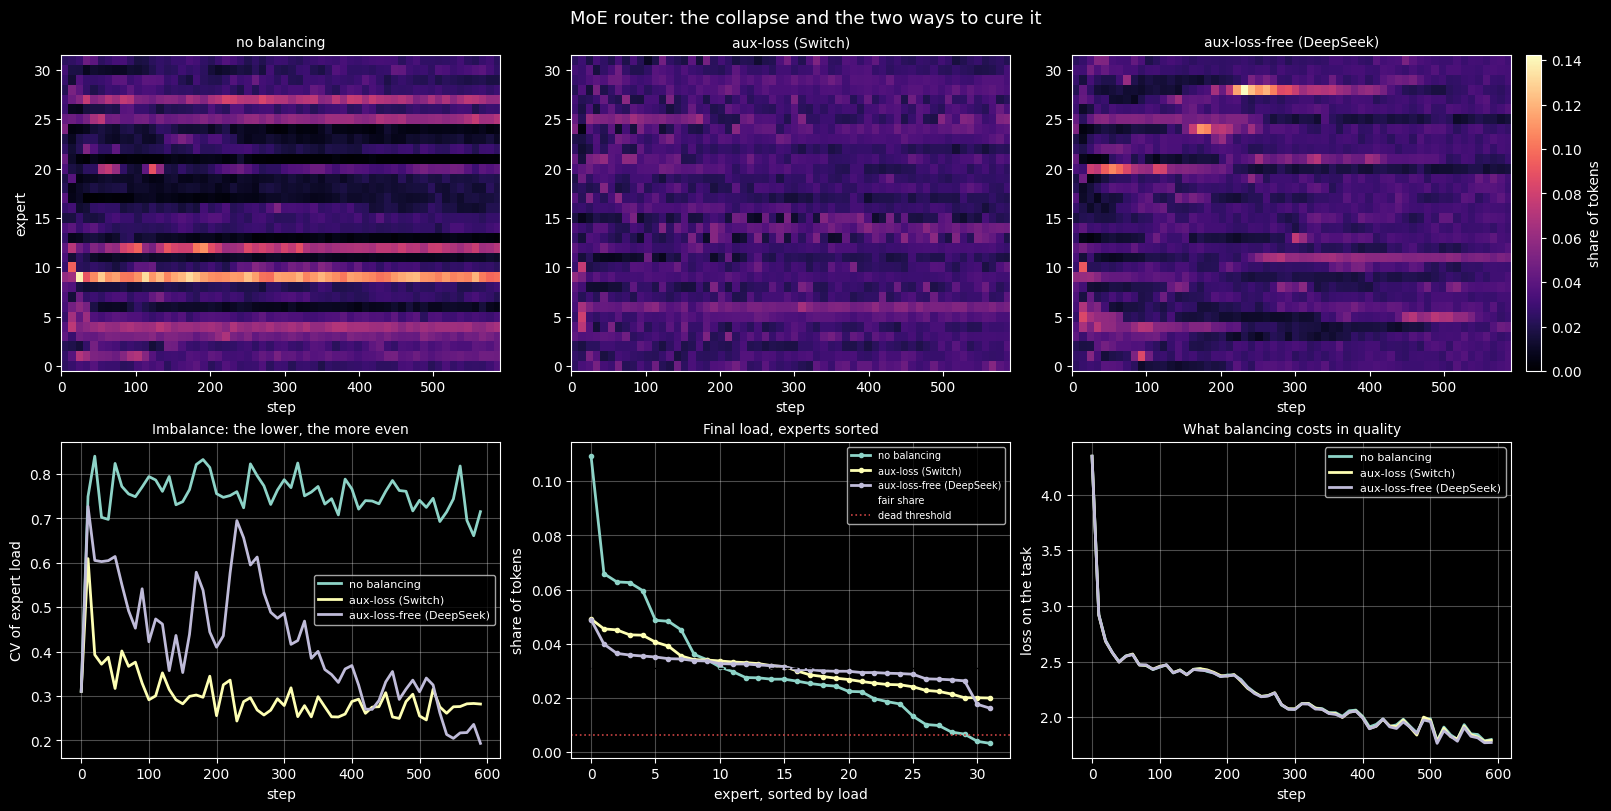

→ out\04_moe_balancing.png


In [23]:
fig, ax = plt.subplots(2, 3, figsize=(16, 8), layout="constrained")
labels = list(RUNS)

# top row: who gets the tokens, step by step. A column that goes dark stays dark.
hot = max(float(torch.tensor(RUNS[l][1]["load"]).max()) for l in labels)
for j, label in enumerate(labels):
    _, h, _ = RUNS[label]
    im = ax[0, j].imshow(torch.tensor(h["load"]).T.numpy(), aspect="auto", origin="lower",
                         cmap="magma", vmin=0, vmax=hot,
                         extent=[0, h["step"][-1], -.5, N_EXPERTS - .5])
    ax[0, j].set_title(label, fontsize=10)
    ax[0, j].set_xlabel("step")
    if j == 0:
        ax[0, j].set_ylabel("expert")
fig.colorbar(im, ax=ax[0, :].tolist(), label="share of tokens", pad=.01)

for label in labels:
    _, h, _ = RUNS[label]
    ax[1, 0].plot(h["step"], h["cv"], lw=2, label=label)
    ax[1, 2].plot(h["step"], h["loss"], lw=2, label=label)
ax[1, 0].set_xlabel("step"); ax[1, 0].set_ylabel("CV of expert load")
ax[1, 0].set_title("Imbalance: the lower, the more even", fontsize=10)
ax[1, 0].legend(fontsize=8); ax[1, 0].grid(alpha=.3)

# sorted, so the head and the starved tail are readable at 32 experts
for label in labels:
    _, _, ld = RUNS[label]
    ax[1, 1].plot(range(N_EXPERTS), ld.sort(descending=True).values.numpy(),
                  lw=2, marker="o", ms=3, label=label)
ax[1, 1].axhline(1 / N_EXPERTS, ls="--", c="k", lw=1, label="fair share")
ax[1, 1].axhline(0.2 / N_EXPERTS, ls=":", c="#c44", lw=1.2, label="dead threshold")
ax[1, 1].set_xlabel("expert, sorted by load"); ax[1, 1].set_ylabel("share of tokens")
ax[1, 1].set_title("Final load, experts sorted", fontsize=10)
ax[1, 1].legend(fontsize=7); ax[1, 1].grid(alpha=.3)

ax[1, 2].set_xlabel("step"); ax[1, 2].set_ylabel("loss on the task")
ax[1, 2].set_title("What balancing costs in quality", fontsize=10)
ax[1, 2].legend(fontsize=8); ax[1, 2].grid(alpha=.3)

fig.suptitle("MoE router: the collapse and the two ways to cure it", fontsize=13)
fig.savefig(OUT / "04_moe_balancing.png", dpi=140)
plt.show()
print(f"→ {OUT / '04_moe_balancing.png'}")

## 6. What the router actually learned

The load being uniform says nothing about whether the split makes sense. On a char-level
model we can look directly: which expert does each character go to?

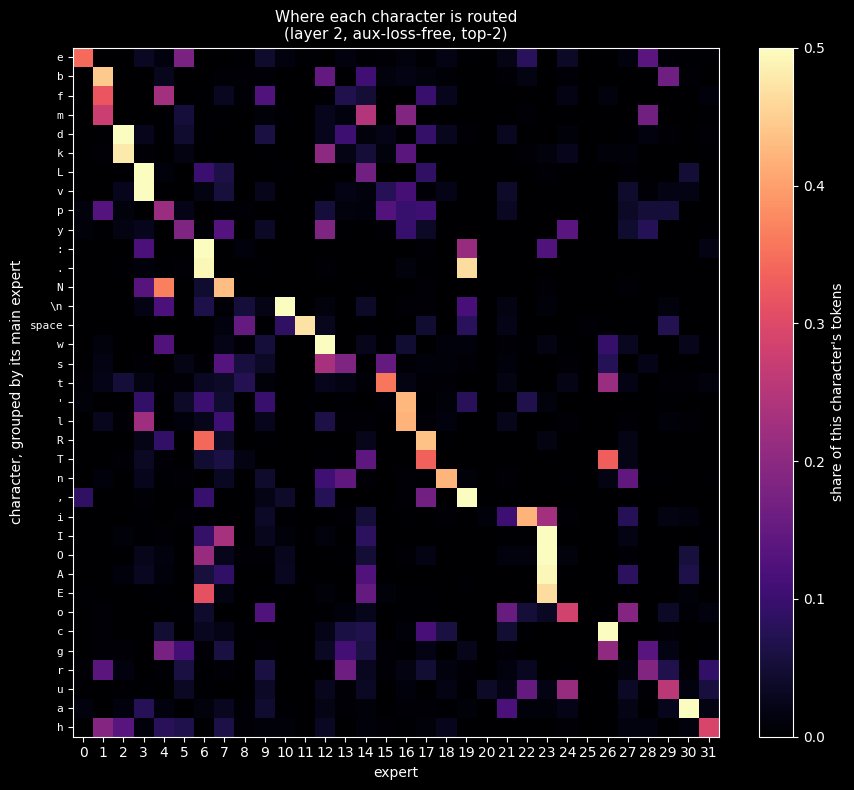

→ out\04_moe_routing.png

Characters that share a dominant expert:
  expert  1: b f m
  expert  2: d k
  expert  3: L v
  expert  6: : .
  expert 12: w s
  expert 16: ' l
  expert 17: R T
  expert 23: I O A E
  expert 26: c g

On average a character sends 40% of its tokens to its single most-used expert
(a uniform router would give 3%). The router is not splitting traffic at
random to satisfy the balancer — it is sorting, and the balancing keeps that sorting from
piling onto a handful of experts.



In [24]:
@torch.no_grad()
def routing_table(m: MoEGPT, layer: int = -1, n_batches: int = 8):
    """For every character, the distribution of its tokens over experts."""
    moe = m.moes()[layer]
    tab = torch.zeros(V, N_EXPERTS)
    for _ in range(n_batches):
        x, _ = batch(bs=32)
        h = m.tok(x) + m.pos(torch.arange(x.size(1)))
        for b in m.blocks[:layer if layer >= 0 else LAYERS + layer]:
            h = b(h)
        blk = m.blocks[layer]
        B, T, C = h.shape
        q, k, v = blk.qkv(blk.n1(h)).view(B, T, 3, HEADS, C // HEADS).permute(2, 0, 3, 1, 4)
        a = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        h = h + blk.o(a.transpose(1, 2).reshape(B, T, C))
        flat = blk.n2(h).reshape(-1, C)
        logits = moe.router(flat)
        route = logits + moe.expert_bias if moe.balance == "bias" else logits
        _, idx = route.topk(TOP_K, -1)
        ids = x.reshape(-1)
        for k_ in range(TOP_K):
            tab.index_put_((ids, idx[:, k_]), torch.ones(len(ids)), accumulate=True)
    return tab


m_bal = RUNS["aux-loss-free (DeepSeek)"][0]
tab = routing_table(m_bal)
seen = tab.sum(1) > 0
order = torch.argsort(tab.sum(1), descending=True)
order = order[seen[order]][:36]                      # the 36 most frequent characters
rows = tab[order] / tab[order].sum(1, keepdim=True)
# group the characters that share a dominant expert, so the structure is visible as blocks
# rather than scattered dots; within a group, the most committed character comes first
key = rows.argmax(1).float() + (1 - rows.max(1).values) * 0.5
perm = torch.argsort(key)
rows, order = rows[perm], order[perm]

fig2, ax2 = plt.subplots(figsize=(9, 8))
im2 = ax2.imshow(rows.numpy(), aspect="auto", cmap="magma", vmin=0, vmax=float(rows.max()))
ax2.set_yticks(range(len(order)))
def _label(i):
    c = itos[int(i)]
    return "space" if c == " " else repr(c)[1:-1]


ax2.set_yticklabels([_label(i) for i in order], fontsize=8, fontfamily="monospace")
ax2.set_xticks(range(N_EXPERTS))
ax2.set_xlabel("expert"); ax2.set_ylabel("character, grouped by its main expert")
ax2.set_title(f"Where each character is routed\n(layer {LAYERS}, aux-loss-free, top-{TOP_K})",
              fontsize=11)
fig2.colorbar(im2, ax=ax2, label="share of this character's tokens")
fig2.tight_layout(); fig2.savefig(OUT / "04_moe_routing.png", dpi=140)
plt.show()
print(f"→ {OUT / '04_moe_routing.png'}")

groups: dict[int, list[str]] = {}
for row, ch in zip(rows, order):
    groups.setdefault(int(row.argmax()), []).append(_label(ch))
shared = {e: cs for e, cs in sorted(groups.items()) if len(cs) > 1}
print("\nCharacters that share a dominant expert:")
for e, cs in shared.items():
    print(f"  expert {e:>2}: " + " ".join(cs))

conc = float((rows.max(1).values).mean())
print(f"""
On average a character sends {100 * conc:.0f}% of its tokens to its single most-used expert
(a uniform router would give {100 / N_EXPERTS:.0f}%). The router is not splitting traffic at
random to satisfy the balancer — it is sorting, and the balancing keeps that sorting from
piling onto a handful of experts.
""")

## 7. The arithmetic: what MoE actually buys

MoE in one line: **hold the parameters of a big model, pay the compute of a small one.**
We count on a config close to DeepSeek-V3.

In [25]:
d, d_ff_dense, d_ff_exp = 7168, 18432, 2048
n_routed, n_shared, k = 256, 1, 8
dense_ffn = 3 * d * d_ff_dense
moe_total = 3 * d * d_ff_exp * (n_routed + n_shared)
moe_active = 3 * d * d_ff_exp * (k + n_shared)
print("FFN of a single layer, parameters:")
print(f"  dense (d_ff={d_ff_dense}):            {dense_ffn / 1e6:>10.0f}M")
print(f"  MoE, total ({n_routed}+{n_shared} experts):    {moe_total / 1e6:>10.0f}M   "
      f"= x{moe_total / dense_ffn:.1f} vs dense")
print(f"  MoE, active (top-{k}+{n_shared}):         {moe_active / 1e6:>10.0f}M   "
      f"= x{moe_active / dense_ffn:.2f} vs dense")
print(f"\n  capacity grew by a factor of {moe_total / dense_ffn:.1f}, compute — by "
      f"{moe_active / dense_ffn:.2f}")
print(f"""
The x{moe_active / dense_ffn:.2f} is not a coincidence: {k} routed experts + {n_shared} shared one at width
{d_ff_exp} give {d_ff_exp * (k + n_shared)}, which is exactly the `intermediate_size` of their own dense
layers. The expert width is chosen so that an MoE layer costs what the dense layer it replaced
cost. All the extra capacity is paid for in memory, not in compute.

**The shared expert** is the `+1` above, and it follows from the rest of the design: once the
experts became narrow ({d_ff_exp} against {d_ff_dense}) and numerous, none of them has room left for the
part every token needs. So that part is factored out into an expert that runs for every token,
and the routed ones are left to specialize.

What is NOT free:
  • memory for the weights. All 671B have to be held somewhere even though 37B are computed.
    Hence expert parallelism and the demands on the interconnect;
  • all-to-all communication: tokens physically travel to their experts and back.
    On a weak network this dominates everything else;
  • capacity factor and token dropping: if more tokens arrive at an expert than fit in its
    buffer, the excess is dropped or sent to overflow — a source of train/inference mismatch;
  • batch dependence: through the balancing, the result for a token depends on which other
    tokens happened to share its batch. At inference that can break reproducibility.
""")

FFN of a single layer, parameters:
  dense (d_ff=18432):                   396M
  MoE, total (256+1 experts):         11318M   = x28.6 vs dense
  MoE, active (top-8+1):                396M   = x1.00 vs dense

  capacity grew by a factor of 28.6, compute — by 1.00

The x1.00 is not a coincidence: 8 routed experts + 1 shared one at width
2048 give 18432, which is exactly the `intermediate_size` of their own dense
layers. The expert width is chosen so that an MoE layer costs what the dense layer it replaced
cost. All the extra capacity is paid for in memory, not in compute.

**The shared expert** is the `+1` above, and it follows from the rest of the design: once the
experts became narrow (2048 against 18432) and numerous, none of them has room left for the
part every token needs. So that part is factored out into an expert that runs for every token,
and the routed ones are left to specialize.

What is NOT free:
  • memory for the weights. All 671B have to be held somewhere even though 37

## Takeaways: MoE
* The router collapses on its own. It is not a rare bug, it is what the feedback loop does
  whenever the loss is not solved exactly — which is always, on a real task.
* Two generations of the cure: an auxiliary loss inside the objective, then a logit shift
  updated outside the gradient. The second leaves the objective alone.
* MoE changes the ratio of capacity to compute. It does not make memory or communication
  go away.
* The metrics that matter for MoE are not about quality but about **distribution**: the load
  CV, the number of dead experts, where each token is routed.

**Not covered here:** expert-choice routing, capacity factor and token dropping,
a top-1/top-2/top-8 comparison, MoE-specific optimizers and initialization.

---

# 06 — The parameter budget: reading a model card as a cost estimate

**Lecture 2, block 4** (the shape of the model and the parameter budget).

The goal of this block is to learn to say, from the seven numbers in `config.json`, where
the parameters live, how much memory that is and how many FLOPs a token costs.

What we do:
1. an exact parameter counter driven by the config (dense, GQA, MLA, MoE);
2. checking the `≈12·L·d²` rule against the exact count — where it lies and why;
3. a table of real models + `--fetch` to check against the live `config.json` files;
4. three plots: the share of the embeddings vs model size, the aspect ratio `d/L`,
   and the breakdown of the budget by what it is spent on.

Dependencies: `matplotlib` (torch is not needed — this is pure arithmetic).

In [26]:
from __future__ import annotations

import json
import sys
import urllib.request
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8", errors="replace")

OUT = Path("out")
OUT.mkdir(exist_ok=True)

## 1. The counter

The formulas worth keeping in your head:

```
embedding        = V · d                        (+ another V·d if the head is not tied)
attention (MHA)  = 4 · d²                        per layer
attention (GQA)  = 2·d² + 2·d·(n_kv · d_head)   per layer
FFN (dense GELU) = 2 · d · d_ff  ≈ 8d²           at d_ff = 4d
FFN (SwiGLU)     = 3 · d · d_ff  ≈ 8d²           at d_ff = 8/3·d  ← deliberately so
FFN (MoE)        = 3 · d · d_ff_expert · N_experts
norms            ≈ 2 · d per layer               (negligible)
```

In [27]:
@dataclass
class Spec:
    name: str
    L: int                     # layers
    d: int                     # d_model
    n_heads: int
    n_kv: int                  # KV heads (0 if MLA)
    d_head: int
    d_ff: int                  # for MoE — the width of ONE expert
    vocab: int
    tied: bool = False
    glu: bool = True           # SwiGLU (3 matrices) or a plain MLP (2)
    # MoE
    n_experts: int = 0
    n_active: int = 0
    n_shared: int = 0
    d_ff_dense: int = 0        # the first dense layers in DeepSeek/Qwen3-MoE
    n_dense_layers: int = 0
    # MLA
    kv_lora: int = 0
    q_lora: int = 0
    d_nope: int = 0
    d_rope: int = 0
    d_v: int = 0
    # misc
    swa: int = 0
    rope_theta: float = 0.0
    note: str = ""
    reported_total_b: float = 0.0    # what the model card says, billions
    reported_active_b: float = 0.0

    # --- the attention parameters of a single layer
    def attn_per_layer(self) -> int:
        if self.kv_lora:                                   # MLA
            h, dn, dr, dv = self.n_heads, self.d_nope, self.d_rope, self.d_v
            wq = self.d * self.q_lora + self.q_lora * h * (dn + dr)
            wkv = self.d * self.kv_lora + self.kv_lora * h * (dn + dv) + self.d * dr
            wo = h * dv * self.d
            return wq + wkv + wo
        q = self.d * self.n_heads * self.d_head
        kv = 2 * self.d * self.n_kv * self.d_head
        o = self.n_heads * self.d_head * self.d
        return q + kv + o

    def _ffn(self, d_ff: int) -> int:
        return (3 if self.glu else 2) * self.d * d_ff

    def ffn_per_layer(self, layer_idx: int) -> tuple[int, int]:
        """(total, active) FFN parameters in one layer."""
        if self.n_experts and layer_idx >= self.n_dense_layers:
            one = self._ffn(self.d_ff)
            total = one * (self.n_experts + self.n_shared) + self.d * self.n_experts
            active = one * (self.n_active + self.n_shared) + self.d * self.n_experts
            return total, active
        d_ff = self.d_ff_dense or self.d_ff
        return self._ffn(d_ff), self._ffn(d_ff)

    def budget(self) -> dict[str, float]:
        emb = self.vocab * self.d
        head = 0 if self.tied else self.vocab * self.d
        attn = self.L * self.attn_per_layer()
        ffn_t = sum(self.ffn_per_layer(i)[0] for i in range(self.L))
        ffn_a = sum(self.ffn_per_layer(i)[1] for i in range(self.L))
        norm = self.L * 2 * self.d + self.d
        total = emb + head + attn + ffn_t + norm
        active = emb + head + attn + ffn_a + norm
        return dict(embedding=emb, lm_head=head, attention=attn, ffn=ffn_t,
                    norm=norm, total=total, active=active)

    def kv_bytes_per_token(self, dtype=2) -> int:
        if self.kv_lora:
            return self.L * (self.kv_lora + self.d_rope) * dtype
        return 2 * self.L * self.n_kv * self.d_head * dtype

    def rule_of_thumb(self) -> int:
        return 12 * self.L * self.d ** 2

    def flops_per_token(self, seq: int) -> float:
        """6N (fwd+bwd over the active parameters) + the attention term, not part of N."""
        n = self.budget()["active"] - self.budget()["embedding"]
        return 6 * n + 12 * self.L * self.n_heads * self.d_head * seq

## 2. Real models

⚠ The numbers are a snapshot of the model cards, so run `--fetch` before relying on
them: the script downloads `config.json` and checks the key fields.

In [28]:
MODELS = [
    Spec("GPT-2 small", 12, 768, 12, 12, 64, 3072, 50257, tied=True, glu=False,
         rope_theta=0, note="2019, the reference point", reported_total_b=0.124),
    Spec("GPT-2 XL", 48, 1600, 25, 25, 64, 6400, 50257, tied=True, glu=False,
         reported_total_b=1.558),
    Spec("Qwen3-0.6B", 28, 1024, 16, 8, 128, 3072, 151936, tied=True,
         rope_theta=1e6, note="SLM: vocabulary = a quarter of the model", reported_total_b=0.6),
    Spec("SmolLM3-3B", 36, 2048, 16, 4, 128, 11008, 128256, tied=True,
         rope_theta=5e6, note="NoPE in every 4th layer", reported_total_b=3.08),
    Spec("Llama-3-8B", 32, 4096, 32, 8, 128, 14336, 128256,
         rope_theta=5e5, note="the consensus stack", reported_total_b=8.03),
    Spec("Qwen3-8B", 36, 4096, 32, 8, 128, 12288, 151936,
         rope_theta=1e6, note="+ QK-norm", reported_total_b=8.2),
    Spec("Qwen3-32B", 64, 5120, 64, 8, 128, 25600, 151936, rope_theta=1e6,
         reported_total_b=32.8),
    Spec("Gemma-3-27B", 62, 5376, 32, 16, 128, 21504, 262144, swa=1024,
         rope_theta=1e6, note="SWA 5:1, sandwich-norm", reported_total_b=27.4),
    Spec("Llama-3-70B", 80, 8192, 64, 8, 128, 28672, 128256, rope_theta=5e5,
         reported_total_b=70.6),
    Spec("gpt-oss-20B", 24, 2880, 64, 8, 64, 2880, 201088, n_experts=32, n_active=4,
         swa=128, note="MoE + SWA on every other layer + attn sinks",
         reported_total_b=20.9, reported_active_b=3.6),
    Spec("gpt-oss-120B", 36, 2880, 64, 8, 64, 2880, 201088, n_experts=128, n_active=4,
         swa=128, reported_total_b=116.8, reported_active_b=5.1),
    Spec("DeepSeek-V3", 61, 7168, 128, 0, 128, 2048, 129280, n_experts=256, n_active=8,
         n_shared=1, d_ff_dense=18432, n_dense_layers=3,
         kv_lora=512, q_lora=1536, d_nope=128, d_rope=64, d_v=128,
         note="MLA + fine-grained MoE", reported_total_b=671.0, reported_active_b=37.0),
    Spec("Kimi K2", 61, 7168, 64, 0, 128, 2048, 163840, n_experts=384, n_active=8,
         n_shared=1, d_ff_dense=18432, n_dense_layers=1,
         kv_lora=512, q_lora=1536, d_nope=128, d_rope=64, d_v=128,
         note="the DeepSeek base, scaled to 1T", reported_total_b=1000.0, reported_active_b=32.0),
]

print(f"{'model':<14}{'our count':>10}{'model card':>12}{'active':>10}"
      f"{'emb+head':>10}{'attn':>8}{'ffn':>9}{'12Ld²':>9}{'d/L':>7}")
print("-" * 96)
B = lambda v: f"{v / 1e9:.2f}B" if v < 1e10 else f"{v / 1e9:.0f}B"
for m in MODELS:
    b = m.budget()
    print(f"{m.name:<14}{B(b['total']):>10}"
          f"{(f'{m.reported_total_b:.2f}B' if m.reported_total_b < 10 else f'{m.reported_total_b:.0f}B'):>12}"
          f"{B(b['active']):>10}{B(b['embedding'] + b['lm_head']):>10}"
          f"{B(b['attention']):>8}{B(b['ffn']):>9}{B(m.rule_of_thumb()):>9}"
          f"{m.d / m.L:>7.0f}")

small = [m.d / m.L for m in MODELS if m.reported_total_b < 5]
big = [m.d / m.L for m in MODELS if m.reported_total_b >= 5]
sizes = [m.reported_total_b for m in MODELS]
print(f"""
How to read this table:

1. "Our count" vs "model card" — discrepancies of a few percent are normal: the cards round
   and count the embeddings differently. A large discrepancy is a reason to re-check the
   config (that is exactly what --fetch is for).

2. The "12·L·d²" rule works decently for dense models of medium size and lies catastrophically
   for MoE (there the capacity sits in the experts) and for SLMs (there the vocabulary
   dominates). The rule is worth memorizing, but with exactly those two caveats.

3. The d/L column is the aspect ratio. It grows with model size: under 5B it runs
   {min(small):.0f}-{max(small):.0f}, above 5B it is {min(big):.0f}-{max(big):.0f}. A model that is too
   "thin and long" parallelizes badly and converges worse, one that is too "thick and short" loses
   quality at an equal parameter count. Across the table the ratio moves by a factor of
   {max(small + big) / min(small + big):.1f} while the parameter count moves by a factor of {max(sizes) / min(sizes):.0f}.

4. Qwen3-0.6B: emb+head ≈ 0.16B out of 0.6B — a quarter of the model sits in the vocabulary,
   and that is AFTER weight tying: "the tokenizer is the first line item of the estimate".
""")

model          our count  model card    active  emb+head    attn      ffn    12Ld²    d/L
------------------------------------------------------------------------------------------------
GPT-2 small        0.12B       0.12B     0.12B     0.04B   0.03B    0.06B    0.08B     64
GPT-2 XL           1.56B       1.56B     1.56B     0.08B   0.49B    0.98B    1.47B     33
Qwen3-0.6B         0.60B       0.60B     0.60B     0.16B   0.18B    0.26B    0.35B     37
SmolLM3-3B         3.08B       3.08B     3.08B     0.26B   0.38B    2.43B    1.81B     57
Llama-3-8B         8.03B       8.03B     8.03B     1.05B   1.34B    5.64B    6.44B    128
Qwen3-8B           8.19B       8.20B     8.19B     1.24B   1.51B    5.44B    7.25B    114
Qwen3-32B            33B         33B       33B     1.56B   6.04B      25B      20B     80
Gemma-3-27B          28B         27B       28B     2.82B   4.10B      22B      22B     87
Llama-3-70B          71B         71B       71B     2.10B     12B      56B      64B    102
gpt

### A digression: what "active parameters" means — and why the numbers do not add up

For MoE models the card says "671B / 37B active". Our count gives 38B.
The gap is exactly the **size of lm_head**: vendors count as active the parameters
that take part in computing the *representation* of a token, and leave the output projection
(`d × V`) out of it. Let us check that hypothesis.

In [29]:
print(f"{'model':<14}{'our active':>12}{'w/o lm_head':>13}{'model card':>12}")
print("-" * 51)
for m in MODELS:
    if not m.reported_active_b:
        continue
    b = m.budget()
    print(f"{m.name:<14}{b['active'] / 1e9:>11.1f}B{(b['active'] - b['lm_head']) / 1e9:>12.1f}B"
          f"{m.reported_active_b:>11.1f}B")
print("""
The "w/o lm_head" column agrees with the model cards almost exactly. The practical lesson:
ASK what exactly was counted. "Active parameters", "parameters without embeddings" and
"non-embedding params" from scaling laws are three different numbers, and the confusion
between them regularly ruins model comparisons in papers and posts.
""")

model           our active  w/o lm_head  model card
---------------------------------------------------
gpt-oss-20B           4.2B         3.6B        3.6B
gpt-oss-120B          5.7B         5.1B        5.1B
DeepSeek-V3          37.6B        36.6B       37.0B
Kimi K2              32.9B        31.7B       32.0B

The "w/o lm_head" column agrees with the model cards almost exactly. The practical lesson:
ASK what exactly was counted. "Active parameters", "parameters without embeddings" and
"non-embedding params" from scaling laws are three different numbers, and the confusion
between them regularly ruins model comparisons in papers and posts.



## 3. Plots

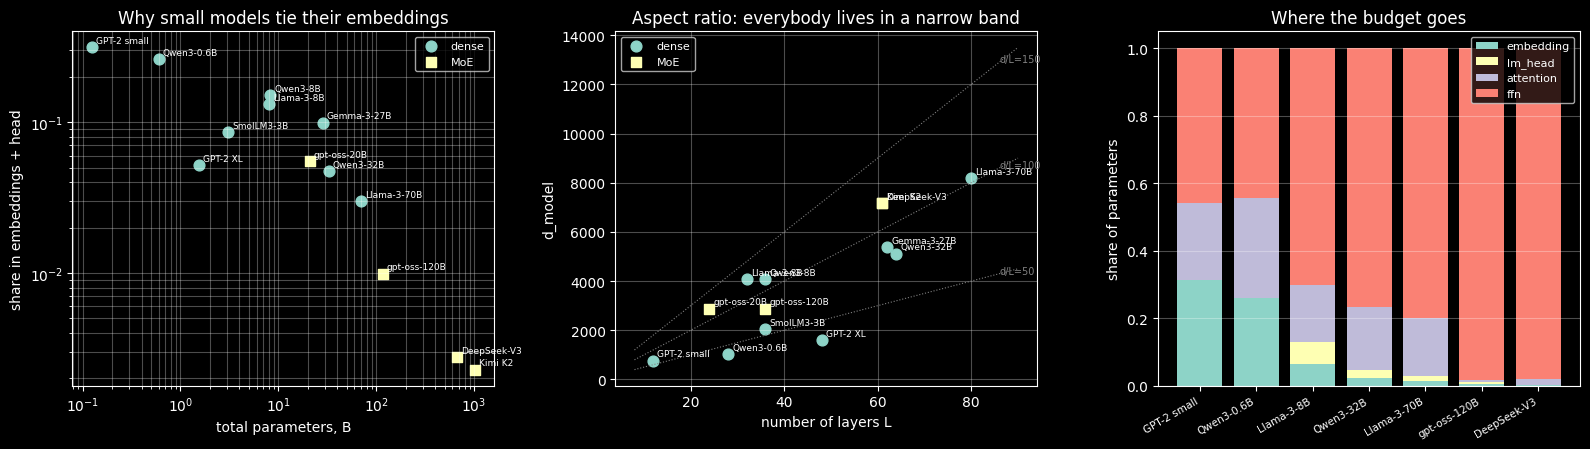

→ out\06_param_budget.png


In [30]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))

dense = [m for m in MODELS if not m.n_experts]
moe = [m for m in MODELS if m.n_experts]
for group, mk, lbl in [(dense, "o", "dense"), (moe, "s", "MoE")]:
    xs = [m.budget()["total"] / 1e9 for m in group]
    ys = [(m.budget()["embedding"] + m.budget()["lm_head"]) / m.budget()["total"] for m in group]
    ax[0].scatter(xs, ys, s=60, marker=mk, label=lbl)
    for m, x, y in zip(group, xs, ys):
        ax[0].annotate(m.name, (x, y), fontsize=6.5, xytext=(3, 3), textcoords="offset points")
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("total parameters, B"); ax[0].set_ylabel("share in embeddings + head")
ax[0].set_title("Why small models tie their embeddings")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3, which="both")

for group, mk, lbl in [(dense, "o", "dense"), (moe, "s", "MoE")]:
    ax[1].scatter([m.L for m in group], [m.d for m in group], s=60, marker=mk, label=lbl)
    for m in group:
        ax[1].annotate(m.name, (m.L, m.d), fontsize=6.5, xytext=(3, 3), textcoords="offset points")
for r in (50, 100, 150):
    ls = [8, 90]
    ax[1].plot(ls, [r * l for l in ls], ":", c="gray", lw=.8)
    ax[1].text(86, r * 86, f"d/L={r}", fontsize=7, color="gray")
ax[1].set_xlabel("number of layers L"); ax[1].set_ylabel("d_model")
ax[1].set_title("Aspect ratio: everybody lives in a narrow band")
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)

show = ["GPT-2 small", "Qwen3-0.6B", "Llama-3-8B", "Qwen3-32B", "Llama-3-70B",
        "gpt-oss-120B", "DeepSeek-V3"]
sel = [m for m in MODELS if m.name in show]
keys = ["embedding", "lm_head", "attention", "ffn"]
bottom = [0.0] * len(sel)
for k in keys:
    vals = [m.budget()[k] / m.budget()["total"] for m in sel]
    ax[2].bar(range(len(sel)), vals, bottom=bottom, label=k)
    bottom = [b + v for b, v in zip(bottom, vals)]
ax[2].set_xticks(range(len(sel)))
ax[2].set_xticklabels([m.name for m in sel], rotation=30, ha="right", fontsize=7.5)
ax[2].set_ylabel("share of parameters")
ax[2].set_title("Where the budget goes")
ax[2].legend(fontsize=8); ax[2].grid(alpha=.3, axis="y")

fig.tight_layout(); fig.savefig(OUT / "06_param_budget.png", dpi=140)
plt.show()
print(f"→ {OUT / '06_param_budget.png'}")

## 4. FLOPs and memory: the same thing in different units

In [31]:
print(f"{'model':<14}{'weights bf16':>12}{'FLOPs/token @8k':>18}{'KV, KB/tok':>13}"
      f"{'cache@128k b=1':>16}")
print("-" * 74)
for m in MODELS:
    b = m.budget()
    w = b["total"] * 2 / 2 ** 30
    fl = m.flops_per_token(8192)
    kv = m.kv_bytes_per_token()
    print(f"{m.name:<14}{w:>11.1f}G{fl / 1e9:>17.1f}G{kv / 1024:>13.1f}"
          f"{kv * 131072 / 2 ** 30:>15.1f}G")

print("""
Three numbers you should be able to quote about any model:
  • the weights — will it fit into one card (and how many cards are needed);
  • FLOPs/token — what training and prefill cost;
  • KB of cache per token — how many requests fit in parallel at inference time.
For MoE the first two diverge radically, and that is the main reason MoE exists at all.
""")

model         weights bf16   FLOPs/token @8k   KV, KB/tok  cache@128k b=1
--------------------------------------------------------------------------
GPT-2 small           0.2G              1.4G         36.0            4.5G
GPT-2 XL              2.9G             16.4G        300.0           37.5G
Qwen3-0.6B            1.1G              8.3G        112.0           14.0G
SmolLM3-3B            5.7G             24.1G         72.0            9.0G
Llama-3-8B           15.0G             57.9G        128.0           16.0G
Qwen3-8B             15.3G             59.9G        144.0           18.0G
Qwen3-32B            61.0G            243.4G        256.0           32.0G
Gemma-3-27B          52.9G            187.0G        496.0           62.0G
Llama-3-70B         131.4G            481.4G        320.0           40.0G
gpt-oss-20B          38.9G             31.3G         48.0            6.0G
gpt-oss-120B        217.5G             45.3G         72.0            9.0G
DeepSeek-V3        1249.9G           

## 5. Checking against the live configs (`--fetch`)

In [32]:
HF_IDS = {
    "GPT-2 small": "openai-community/gpt2",
    "Qwen3-0.6B": "Qwen/Qwen3-0.6B",
    "Qwen3-8B": "Qwen/Qwen3-8B",
    "Qwen3-32B": "Qwen/Qwen3-32B",
    "SmolLM3-3B": "HuggingFaceTB/SmolLM3-3B",
    "gpt-oss-20B": "openai/gpt-oss-20b",
    "gpt-oss-120B": "openai/gpt-oss-120b",
    "DeepSeek-V3": "deepseek-ai/DeepSeek-V3",
    "Kimi K2": "moonshotai/Kimi-K2-Instruct",
    "Llama-3-8B": "meta-llama/Meta-Llama-3-8B",       # gated
    "Gemma-3-27B": "google/gemma-3-27b-it",           # gated
}
CHECK = {                     # our field → the field in config.json
    "L": "num_hidden_layers", "d": "hidden_size", "n_heads": "num_attention_heads",
    "n_kv": "num_key_value_heads", "vocab": "vocab_size", "rope_theta": "rope_theta",
    "kv_lora": "kv_lora_rank", "n_experts": ("num_local_experts", "n_routed_experts"),
}

if "--fetch" in sys.argv:
    by_name = {m.name: m for m in MODELS}
    for name, hid in HF_IDS.items():
        try:
            with urllib.request.urlopen(
                    f"https://huggingface.co/{hid}/raw/main/config.json", timeout=20) as r:
                cfg = json.load(r)
        except Exception as e:
            print(f"{name:<14} — download failed ({type(e).__name__}); the model may be gated")
            continue
        m, bad = by_name[name], []
        for ours, theirs in CHECK.items():
            keys = theirs if isinstance(theirs, tuple) else (theirs,)
            val = next((cfg[k] for k in keys if k in cfg), None)
            if val is None:
                continue
            mine = getattr(m, ours)
            if mine and abs(float(val) - float(mine)) > 1e-6:
                bad.append(f"{ours}: ours {mine}, the config says {val}")
        print(f"{name:<14} {'✓ matches' if not bad else '✗ ' + '; '.join(bad)}")
else:
    print("Run with --fetch to check the table against the live config.json files on HF.")
    print("(gated repos such as Llama/Gemma will not serve it without a token — that is normal)")

Run with --fetch to check the table against the live config.json files on HF.
(gated repos such as Llama/Gemma will not serve it without a token — that is normal)


## Takeaways: the parameter budget
* `config.json` is a cost estimate: seven numbers set memory, compute and the price of inference.
* FFN dominates in dense models, the vocabulary in small ones, the experts in MoE.
* `12·L·d²` is a working rule for dense models, but not for MoE and not for SLMs.
* The aspect ratio `d/L` moves within a factor of four while the models grow by four
  orders of magnitude. It is an empirical consensus; nothing forces it.

**Exercise:** take the config of a model you have not seen before and name its size, its
vocabulary share and its cache per token.

---

# 07 — The residual stream from the inside: logit lens and the contribution of layers

**Lecture 2, block 3** (the residual stream as an additive backbone).

Structurally the stream is simple: layers read from a shared stream and write into it.
Here we **cut it open** on a trained model and show four things:

1. **logit lens** — decoding the residual after every layer through the final norm and
   the unembedding shows how the prediction assembles with depth. Literally:
   "at layer 2 the model thinks X, at layer 5 — Y".
2. **the growth of the norm** of the stream across layers — and what it means.
3. **ablations**: zero out the output of one sublayer → see how much the loss grows.
   That is how one finds out which layers actually carry the work.
4. **direct logit attribution**: we decompose the final logit into sublayer contributions.

We train the model ourselves at the character level so that the predictions
can be **read with the naked eye**. The corpus is tinyshakespeare, the same one as in `03`.

Runtime ~8.5 minutes on CPU, most of it the training and the ablation sweep.
Dependencies: `torch`, `matplotlib`.

On the logit lens: nostalgebraist, 2020 —
https://www.lesswrong.com/posts/AcKRB8wDpdaN6v6ru/interpreting-gpt-the-logit-lens

In [33]:
from __future__ import annotations

import sys
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8", errors="replace")

OUT = Path("out")
OUT.mkdir(exist_ok=True)
torch.manual_seed(0)

In [34]:
FALLBACK = ("To be, or not to be, that is the question: whether tis nobler in the mind "
            "to suffer the slings and arrows of outrageous fortune. " * 200)
path = OUT / "tinyshakespeare.txt"
if not path.exists():
    try:
        with urllib.request.urlopen(
                "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/"
                "tinyshakespeare/input.txt", timeout=30) as r:
            path.write_text(r.read().decode("utf-8"), encoding="utf-8")
    except Exception:
        path.write_text(FALLBACK, encoding="utf-8")
text = path.read_text(encoding="utf-8")
chars = sorted(set(text))
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}
data = torch.tensor([stoi[c] for c in text])
V, BLOCK, D, HEADS, LAYERS = len(chars), 96, 128, 4, 6
print(f"alphabet {V}, corpus {len(text)} characters, model {LAYERS} layers × {D}")

alphabet 65, corpus 1115394 characters, model 6 layers × 128


## A model that can hand out its intermediate states

The only difference from an ordinary implementation: `forward` collects a list of
residual-stream states after every sublayer, and can zero out a chosen sublayer.

In [35]:
class Block(nn.Module):
    def __init__(self):
        super().__init__()
        self.n1, self.n2 = nn.LayerNorm(D), nn.LayerNorm(D)
        self.qkv, self.o = nn.Linear(D, 3 * D, bias=False), nn.Linear(D, D, bias=False)
        self.up, self.down = nn.Linear(D, 4 * D), nn.Linear(4 * D, D)

    def attn(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(self.n1(x)).view(B, T, 3, HEADS, C // HEADS).permute(2, 0, 3, 1, 4)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        return self.o(y.transpose(1, 2).reshape(B, T, C))

    def mlp(self, x):
        return self.down(F.gelu(self.up(self.n2(x))))


class CharGPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.tok, self.pos = nn.Embedding(V, D), nn.Embedding(BLOCK, D)
        self.blocks = nn.ModuleList([Block() for _ in range(LAYERS)])
        self.nf, self.head = nn.LayerNorm(D), nn.Linear(D, V, bias=False)

    def forward(self, idx, trace=False, ablate: tuple[int, str] | None = None):
        x = self.tok(idx) + self.pos(torch.arange(idx.size(1), device=idx.device))
        states = [("emb", x)]
        contribs = []
        for li, b in enumerate(self.blocks):
            a = b.attn(x)
            if ablate == (li, "attn"):
                a = torch.zeros_like(a)
            x = x + a
            contribs.append((f"L{li}.attn", a))
            if trace:
                states.append((f"L{li}.attn", x))
            m = b.mlp(x)
            if ablate == (li, "mlp"):
                m = torch.zeros_like(m)
            x = x + m
            contribs.append((f"L{li}.mlp", m))
            if trace:
                states.append((f"L{li}.mlp", x))
        logits = self.head(self.nf(x))
        return (logits, states, contribs) if trace else logits


model = CharGPT()
opt = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=0.1, betas=(0.9, 0.95))
STEPS = 900
print(f"training {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M parameters...")
for step in range(STEPS):
    ix = torch.randint(len(data) - BLOCK - 1, (32,))
    xb = torch.stack([data[i:i + BLOCK] for i in ix])
    yb = torch.stack([data[i + 1:i + 1 + BLOCK] for i in ix])
    loss = F.cross_entropy(model(xb).view(-1, V), yb.reshape(-1))
    opt.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step()
    if step % 300 == 0:
        print(f"  step {step:>4}  loss {loss.item():.3f}")
model.eval()
print(f"  done, loss {loss.item():.3f}\n")

training 1.22M parameters...
  step    0  loss 4.333
  step  300  loss 1.847
  step  600  loss 1.659
  done, loss 1.511



## 1. Logit lens: reading the model's "thoughts" layer by layer

At any layer the residual stream lives in the same space as the input of the unembedding.
So it can be decoded by that very unembedding — and we get to see what the model
"would have predicted" had it stopped here.

A strict caveat: this is **not** "the model thinks this". It is "cut off the tail, keep the
head, and this is what comes out". The method works on models with Pre-LN and rather
clumsily on some others. But as a first approximation it is priceless.

In [36]:
PROMPT = "First Citizen:\nBefore we proceed any further, hear me speak"
ids = torch.tensor([[stoi[c] for c in PROMPT if c in stoi]])[:, :BLOCK]
with torch.no_grad():
    logits, states, contribs = model(ids, trace=True)


@torch.no_grad()
def lens(h: torch.Tensor) -> torch.Tensor:
    return model.head(model.nf(h))


POSITIONS = list(range(len(ids[0]) - 26, len(ids[0])))
print("logit lens: what the model would predict if it stopped at this layer\n")
head = "layer \\ input:" + "".join(f"{PROMPT[p].replace(chr(10), '⏎'):>3}" for p in POSITIONS)
print(head)
print("-" * len(head))
for name, h in states:
    pred = lens(h)[0].argmax(-1)
    row = "".join(f"{itos[int(pred[p])].replace(chr(10), '⏎'):>3}" for p in POSITIONS)
    print(f"{name:<14}{row}")
true = "".join(f"{PROMPT[p + 1].replace(chr(10), '⏎'):>3}" for p in POSITIONS[:-1])
print(f"{'GROUND TRUTH':<14}{true}")

print("""
What is visible here (and what is worth dwelling on):
  • the `emb` row is the prediction from the current character alone, without context.
    Usually it is garbage there, or "the most frequent next character overall";
  • early layers often simply REPEAT the input — this is "detokenization",
    the assembly of local context;
  • the answer is brought to the correct one in the top third of the stack;
  • at some positions the answer appears early and never changes again — those are the easy
    positions (inside a word). The hard ones are at word and line boundaries.
""")

logit lens: what the model would predict if it stopped at this layer

layer \ input:  a  n  y     f  u  r  t  h  e  r  ,     h  e  a  r     m  e     s  p  e  a  k
--------------------------------------------------------------------------------------------
emb             t  g  m  t  A  l  n  $  &  r  n  P  t  o  r  t  t  k  Y  d  Y  p  p  d  t  A
L0.attn         t  g     e  f  l  t  e  e  r  t     u  o  r  t  l  e  i  n  p  e  r  r  t  n
L0.mlp          t  g     s  f  r  t  h  e  r  v     I  a  r  t  n  w  i  n  w  h  i  r  t  n
L1.attn         t  t     s  o  r  t  e  e  r  e     i  a  r  t     s  a  n  w  e  a  r  t  n
L1.mlp          n  t     s  o  r  e  e  e  r  e     a  a  r  r  d  s  y  n  w  h  e  r  r  e
L2.attn         n        s  o  r  e  e  e  r  e     I  a  r  r     w  a     s  a  e  r  r  e
L2.mlp          n        m  o  r  e  u  e  r        a  a  r  r     w  y     o  h  e  r  r  '
L3.attn         n        m  o  r  e  u  e  r        I  a  r  v  d  w  y  n  w  h  e  r  k  '


## 2. How fast the prediction "converges" — quantitatively

For every layer: the mean log-prob of the correct character and its rank.

‖x‖: input 12.2 → output 62.0 (×5.1)


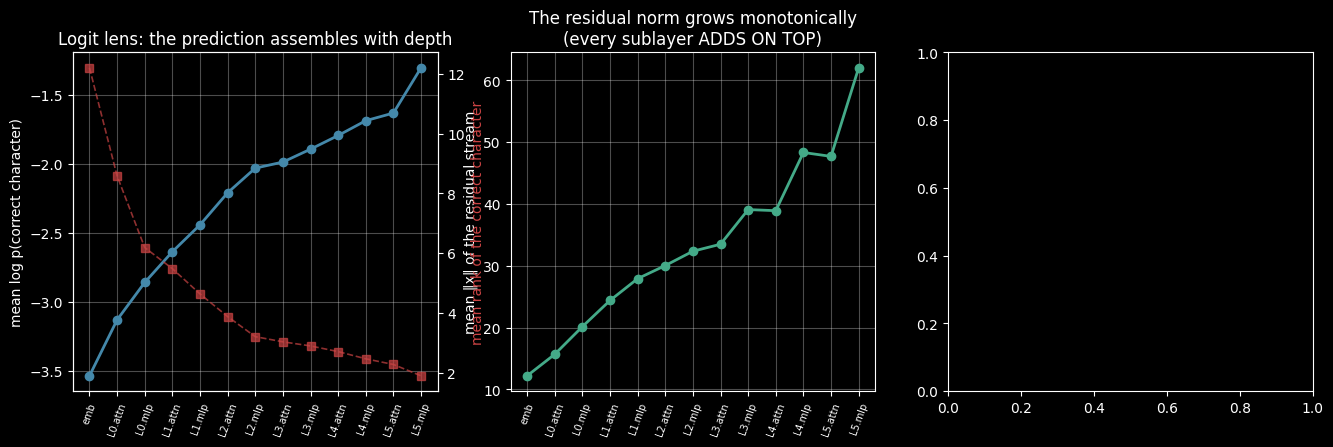

In [37]:
@torch.no_grad()
def lens_metrics(states, ids):
    tgt = ids[0, 1:]
    lp, rk = [], []
    for _, h in states:
        z = lens(h)[0, :-1].log_softmax(-1)
        lp.append(float(z.gather(-1, tgt[:, None]).mean()))
        rk.append(float((z > z.gather(-1, tgt[:, None])).sum(-1).float().mean()))
    return lp, rk


lp, rk = lens_metrics(states, ids)
names = [n for n, _ in states]
norms = [float(h[0].norm(dim=-1).mean()) for _, h in states]

fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))
ax[0].plot(lp, "o-", lw=2, color="#48a")
ax[0].set_xticks(range(len(names)))
ax[0].set_xticklabels(names, rotation=70, fontsize=7)
ax[0].set_ylabel("mean log p(correct character)")
ax[0].set_title("Logit lens: the prediction assembles with depth")
ax[0].grid(alpha=.3)
ax2 = ax[0].twinx()
ax2.plot(rk, "s--", lw=1.2, color="#c44", alpha=.7)
ax2.set_ylabel("mean rank of the correct character", color="#c44")

ax[1].plot(norms, "o-", lw=2, color="#4a8")
ax[1].set_xticks(range(len(names)))
ax[1].set_xticklabels(names, rotation=70, fontsize=7)
ax[1].set_ylabel("mean ‖x‖ of the residual stream")
ax[1].set_title("The residual norm grows monotonically\n(every sublayer ADDS ON TOP)")
ax[1].grid(alpha=.3)
print(f"‖x‖: input {norms[0]:.1f} → output {norms[-1]:.1f} (×{norms[-1] / norms[0]:.1f})")

## 3. Ablations: who is actually doing the work here

We zero out the output of one sublayer (the attention or the MLP of one layer) and look
at how much the loss grows. This is the most direct way to measure a layer's "importance".

In [38]:
@torch.no_grad()
def eval_loss(ablate=None, n_batches=8) -> float:
    tot = 0.0
    g = torch.Generator().manual_seed(7)
    for _ in range(n_batches):
        ix = torch.randint(len(data) - BLOCK - 1, (16,), generator=g)
        xb = torch.stack([data[i:i + BLOCK] for i in ix])
        yb = torch.stack([data[i + 1:i + 1 + BLOCK] for i in ix])
        out = model(xb, ablate=ablate)
        tot += float(F.cross_entropy(out.view(-1, V), yb.reshape(-1)))
    return tot / n_batches


base = eval_loss()
print(f"baseline loss: {base:.3f}\n")
abl_names, abl_vals = [], []
for li in range(LAYERS):
    for kind in ("attn", "mlp"):
        d = eval_loss((li, kind)) - base
        abl_names.append(f"L{li}.{kind}")
        abl_vals.append(d)
        print(f"  zeroed out {f'L{li}.{kind}':<10} Δloss = {d:+.3f}")

colors = ["#48a" if n.endswith("attn") else "#e a".replace(" ", "8") for n in abl_names]
ax[2].bar(range(len(abl_vals)), abl_vals, color=colors)
ax[2].set_xticks(range(len(abl_names)))
ax[2].set_xticklabels(abl_names, rotation=70, fontsize=7)
ax[2].set_ylabel("Δ loss when the sublayer is zeroed out")
ax[2].set_title("Importance of sublayers\n(blue — attention, orange — MLP)")
ax[2].grid(alpha=.3, axis="y")
fig.tight_layout(); fig.savefig(OUT / "07_residual_stream.png", dpi=140)
plt.show()
print(f"\n→ {OUT / '07_residual_stream.png'}")

attn_tot = sum(v for n, v in zip(abl_names, abl_vals) if n.endswith("attn"))
mlp_tot = sum(v for n, v in zip(abl_names, abl_vals) if n.endswith("mlp"))
big, small = max(zip(abl_vals, abl_names)), min(zip(abl_vals, abl_names))
mlp_wins = ", ".join("L%d" % li for li in range(LAYERS)
                     if abl_vals[2 * li + 1] > abl_vals[2 * li])
print(f"""
What to look at:
  • importance is distributed UNEVENLY: {big[1]} costs {big[0]:+.2f} on its own, {small[1]} costs
    {small[0]:+.3f} — a factor of {big[0] / max(small[0], 1e-9):.0f} between the two ends;
  • the load sits at the entrance. Local context is assembled in layer 0 and nothing
    downstream can recover it; the later sublayers can be removed almost painlessly —
    this is the empirical basis for layer pruning and early exit (lecture 9);
  • attention against MLP: {attn_tot:+.2f} in total against {mlp_tot:+.2f}. Take L0.attn out and it
    reverses, {attn_tot - abl_vals[0]:+.2f} against {mlp_tot:+.2f}: layer by layer the MLP is the
    larger of the two in layers {mlp_wins}.
A caveat: zeroing out one layer in a trained network is a crude ablation. The model has never
seen such a state. Cleaner is mean-ablation (replace with the mean over the dataset),
but for a seminar the difference is immaterial.
""")

baseline loss: 1.564

  zeroed out L0.attn    Δloss = +1.625
  zeroed out L0.mlp     Δloss = +0.350
  zeroed out L1.attn    Δloss = +0.219
  zeroed out L1.mlp     Δloss = +0.067
  zeroed out L2.attn    Δloss = +0.206
  zeroed out L2.mlp     Δloss = +0.079
  zeroed out L3.attn    Δloss = +0.076
  zeroed out L3.mlp     Δloss = +0.093
  zeroed out L4.attn    Δloss = +0.060
  zeroed out L4.mlp     Δloss = +0.069
  zeroed out L5.attn    Δloss = +0.025
  zeroed out L5.mlp     Δloss = +0.118

→ out\07_residual_stream.png

What to look at:
  • importance is distributed UNEVENLY: L0.attn costs +1.63 on its own, L5.attn costs
    +0.025 — a factor of 65 between the two ends;
  • the load sits at the entrance. Local context is assembled in layer 0 and nothing
    downstream can recover it; the later sublayers can be removed almost painlessly —
    this is the empirical basis for layer pruning and early exit (lecture 9);
  • attention against MLP: +2.21 in total against +0.77. Take L0.attn out and

## 4. Direct logit attribution

The final logits = `W_head · LN(Σ of contributions)`. Freeze the LN scale and the mapping
becomes linear — so the logit can be **decomposed into a sum** of the contributions of
individual sublayers. This is the basic mech-interp technique (direct logit attribution).

In [39]:
with torch.no_grad():
    x_final = states[-1][1]
    scale = torch.rsqrt(x_final.var(-1, keepdim=True, unbiased=False) + 1e-5)   # the LN scale
    W = model.head.weight * model.nf.weight                                     # (V, d)
    pos = len(ids[0]) - 1
    tgt = int(ids[0, pos])                          # the actual next character in the prompt
    parts = [(name, float((W[tgt] @ (c[0, pos - 1] * scale[0, pos - 1]))))
             for name, c in contribs]
    parts.insert(0, ("emb+pos", float(W[tgt] @ (states[0][1][0, pos - 1] * scale[0, pos - 1]))))

print(f"Logit of {itos[tgt]!r} at position {pos}, decomposed into sublayer contributions:\n")
for name, val in sorted(parts, key=lambda t: -abs(t[1]))[:8]:
    bar = "█" * int(abs(val) * 3)
    print(f"  {name:<12}{val:>+8.2f}  {'' if val >= 0 else '-'}{bar}")
print(f"  {'TOTAL':<12}{sum(v for _, v in parts):>+8.2f}   "
      f"(model logit: {float(logits[0, pos - 1, tgt]):+.2f})")
print("""
The sum of the contributions matches the logit (up to the fact that we froze the LN scale).
This is exactly the operational meaning of the phrase "the residual stream is additive":
the final answer literally COMES APART into terms from individual sublayers.

The whole of mechanistic interpretability rests on this property:
you can ask "which layer is responsible for this particular logit" and get a number.
And it is exactly this property that hyper-connections in DeepSeek V4 generalize — there the
stream is not one but several, with learned connections between them.
""")

Logit of 'k' at position 58, decomposed into sublayer contributions:

  L4.mlp         +2.04  ██████
  L5.mlp         +1.85  █████
  L2.attn        +0.99  ██
  L3.mlp         +0.83  ██
  L0.mlp         +0.66  █
  L3.attn        +0.64  █
  L2.mlp         +0.52  █
  L1.mlp         +0.40  █
  TOTAL          +8.35   (model logit: +8.11)

The sum of the contributions matches the logit (up to the fact that we froze the LN scale).
This is exactly the operational meaning of the phrase "the residual stream is additive":
the final answer literally COMES APART into terms from individual sublayers.

The whole of mechanistic interpretability rests on this property:
you can ask "which layer is responsible for this particular logit" and get a number.
And it is exactly this property that hyper-connections in DeepSeek V4 generalize — there the
stream is not one but several, with learned connections between them.



## 5. The same thing on a real model (Llama-3.2-1B)

Everything above was on our char model: convenient, because the predictions can be read
by eye. But a fair question arises: "is it the same on a real model?". The answer: broadly
yes, and there are important differences worth naming.

The measurement was made on an H100 (`../../week01/materials-seminar/gpu/bench_real_models.py`),
here we only read the JSON.

In [40]:
import json

real_path = OUT / "gpu_real_models.json"
if not real_path.exists():
    print("no out/gpu_real_models.json — section skipped")
else:
    RM = json.loads(real_path.read_text(encoding="utf-8"))
    LL = RM["llama_logit_lens"]
    print(f"prompt: {LL['prompt']!r}")
    print()
    print(f"{'layer':>6}  {'top-1':<16}{'logp of true':>14}{'rank of true':>15}{'‖x‖':>9}")
    print("-" * 64)
    for r in LL["rows"]:
        print(f"{r['layer']:>6}  {r['top1_last']!r:<16}{r['mean_logprob_true']:>14.2f}"
              f"{r['mean_rank_true']:>15.0f}{r['resid_norm']:>9.1f}")

    first, last = LL["rows"][0], LL["rows"][-1]
    print(f"""
What we read here:
  • the rank of the correct token falls from {first['mean_rank_true']:.0f} to {last['mean_rank_true']:.0f} out of 128256 —
    the prediction assembles with depth, exactly as on the toy;
  • the norm of the stream grows from {first['resid_norm']:.1f} to {last['resid_norm']:.1f}, and the last
    jump is the sharpest: the final norm really is needed;
  • BUT in the middle layers top-1 produces garbage ({', '.join(repr(r['top1_last']) for r in LL['rows'][6:9])}).

The last point is not a bug in our code but a known limitation of the logit lens
on Llama-like models: the unembedding is trained to read ONLY the final state,
and the intermediate layers live in a "rotated" basis. The cure is the tuned lens
(Belrose et al., arxiv.org/abs/2303.08112): instead of the bare unembedding, an affine
probe is trained for every layer. On GPT-2 the plain logit lens works noticeably better —
which is in itself an interesting fact about how different models are built.
""")

    AB = RM["llama_ablation"]
    top = sorted(AB["delta"].items(), key=lambda kv: -kv[1])[:8]
    print(f"Sublayer ablations, baseline loss {AB['base_loss']:.3f}:")
    for k, v in top:
        print(f"  {k:<12}Δloss {v:+.3f}  {'█' * int(min(v, 6) * 6)}")
    print("""
The picture is the same as on the toy, and even sharper: the first layers carry almost all
the work, the last mlp matters too, the middle sags gently. This is precisely the empirical
basis for layer pruning and early exit — lecture 9 will be about them.
""")

prompt: 'The capital of France is Paris. The capital of Germany is Berlin. The capital of Italy is Rome. The capital of Spain is'

 layer  top-1             logp of true   rank of true      ‖x‖
----------------------------------------------------------------
     0  ' Spain'                -86.16          52435      0.9
     1  ' Spain'                -28.12          34291      2.9
     2  ' Spain'                -19.56          41303     31.7
     3  ' Spain'                -16.35          39518     32.4
     4  ' Spain'                -14.09          39431     33.1
     5  ' national'             -12.61          38652     33.4
     6  '-desc'                 -12.35          39909     33.9
     7  ' nó'                   -12.72          50570     34.2
     8  ' repression'           -12.14          37490     34.9
     9  ' meanwhile'            -12.50          52721     35.1
    10  '-Israel'                -9.69          17005     36.4
    11  ' Spain'                 -7.45          

## Takeaways: the residual stream
* The residual stream can be read at any depth (logit lens), and the final logit splits
  into a sum of sublayer contributions (DLA) that comes back to the model's own logit.
* The prediction assembles gradually, but unevenly: there are "workhorse" layers
  and layers that change almost nothing.
* The norm of the stream grows monotonically with depth (middle panel). Two standing
  answers to that: the final norm before the head, and damping what each block writes into
  the stream at initialization — our `02` scales the output projections by `1/√(2L)`,
  nanochat sets them to exactly zero, so every block starts as the identity and has to earn
  its contribution.

**Where this leads later in the course:** lecture 9 (pruning, early exit — a direct consequence
of the uneven importance of layers), lecture 14 (mech interp, SAE, activation patching).

---

# 08 — The frontier showcase: a generator for the comparison table and the map

**Lecture 2, block 5** (comparing real architectures along the axes).

The mechanisms have all been covered by now. Here we **do not re-explain** them but
show how the frontier combines them. The script does two things:

1. prints a "model × axis" table in markdown (it pastes straight into the slides);
2. draws a **technique heatmap** — you see at once what converged and what diverged.

⚠ This is a showcase, not a database. The numbers are a snapshot as of 09-2026, taken from
`config.json` files and tech reports. Refresh them before you show this.

Dependencies: `matplotlib`.

In [41]:
from __future__ import annotations

import sys
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8", errors="replace")

OUT = Path("out")
OUT.mkdir(exist_ok=True)

# The context length at which we quote total cache. Any single "KB per token" number is
# a half-truth once a model bounds part of its cache (sliding window) or replaces part of
# it with a fixed-size recurrent state — so we fix a reference length and compare there.
REF_CTX = 131_072

## How the KV numbers here are computed

One formula for every row, or the column means nothing:

* an ordinary attention layer caches `2 (K and V) × n_kv × d_head` values per token;
* an **MLA** layer caches **one** latent of `kv_lora + qk_rope` values — not K and V separately;
* a **sliding-window** layer never exceeds `window` tokens, so it contributes a *constant*,
  not a per-token cost;
* a **linear-attention** layer keeps a fixed-size recurrent state instead of a cache.

Hence two numbers per model: `kv_kb` — the part that **grows** with context, and
`kv_fixed_mb` — the part that does not. Both are bytes **as deployed**, so `cache_gib` is
what actually lands on the card; `r` divides by the stored precision first, because since
09-2026 not every row caches in bf16 and a number format is not an architecture. Quoting only the first hides Gemma's 800 MiB
of window; quoting the naive "all layers are global" figure overstates Gemma-3 by 6×,
Llama-4-Scout by 3.3× and gpt-oss by exactly 2×.

This is not a pedantic distinction. Published write-ups get it wrong routinely: a widely
read set of notes on Muse Glimmer quotes 52 KiB/token, which is simply `52 layers × 1 KiB`
with the sliding window ignored — 3.8× too high at a 131k context. If a number here
disagrees with a blog post, check which of the two counted the windows.

`r` is the dimensionless version: cached values per token divided by `2 · L · d_model`,
i.e. what this model caches relative to plain MHA at the same size. **1.0 is MHA by
construction**; everything below is compression. It is the honest way to compare a 3B
model with a 1.6T one, which raw KB/token cannot do.

In [42]:
@dataclass
class Arch:
    name: str
    year: float                # YYYY.MM — the month is ALWAYS two digits (2024.04 = April)
    attn: str                  # what the table prints
    family: str                # MHA | GQA | MLA | MQA | hybrid — for colouring
    L: int                     # layers
    d_model: int
    kv_kb: float               # KiB per token that GROWS with context, AS DEPLOYED
    kv_fixed_mb: float         # MiB per sequence that does NOT depend on context
    ffn: str                   # dense | MoE
    total_b: float
    active_b: float
    norm: str
    pos: str
    block: str = "serial"      # serial | parallel — how attention and the FFN sit in the stream
    tricks: set[str] = field(default_factory=set)
    line: str = ""             # one phrase: "what this model says to the world"
    kv_bits: int = 16          # precision the cache is STORED in. bf16 everywhere until
                               # DeepSeek-V4.1 shipped an fp4 KV cache in 09-2026

    @property
    def t(self) -> float:
        """A real point on the time axis. Needed because YYYY.MM does not sort as a float:
        December (.12) would land before April (.04·10 = .4) if you compared naively."""
        y = int(self.year)
        month = round((self.year - y) * 100)
        return y + (month - 1) / 12

    @property
    def date(self) -> str:
        return f"{int(self.year)}-{round((self.year - int(self.year)) * 100):02d}"

    @property
    def r(self) -> float:
        """Cached VALUES per token relative to MHA at the same depth and width.

        Counted in values rather than bytes on purpose: a row that stores its cache in fp4
        would otherwise look four times better than the same shape in bf16, and the column
        would be measuring the number format instead of the architecture."""
        values = self.kv_kb * 1024 * 8 / self.kv_bits
        return values / (2 * self.L * self.d_model)

    @property
    def cache_gib(self) -> float:
        """Total cache for one sequence at REF_CTX — defined identically for every design."""
        return self.kv_kb * REF_CTX / 1024 / 1024 + self.kv_fixed_mb / 1024


T = {"weight tying", "attn bias", "GQA", "MLA", "SWA", "linear attn", "sparse attn",
     "index reuse", "K=V", "attn sink", "MoE", "shared experts", "aux-loss-free", "MTP",
     "QK-norm", "gated attn", "sandwich norm", "NoPE", "hyper-conn", "depth attn"}

MODELS = [
    Arch("GPT-2 small", 2019.02, "MHA", "MHA", 12, 768, 36, 0, "dense", 0.124, 0.124,
         "Pre-LN", "learned", "serial", {"weight tying", "attn bias"},
         "the reference point: everything that follows is an edit to this same file"),
    Arch("Llama-2-7B", 2023.07, "MHA", "MHA", 32, 4096, 512, 0, "dense", 6.7, 6.7,
         "Pre-RMSNorm", "RoPE-10k", "serial", set(),
         "the stack has settled: RMSNorm + RoPE + SwiGLU, but the cache is still huge"),
    Arch("Mistral-7B", 2023.09, "GQA + SWA(all)", "GQA", 32, 4096, 0, 512, "dense", 7.2, 7.2,
         "Pre-RMSNorm", "RoPE-10k", "serial", {"GQA", "SWA"},
         "the window is on EVERY layer, so the cache stops growing entirely — 512 MiB, forever"),
    Arch("Llama-3-8B", 2024.04, "GQA", "GQA", 32, 4096, 128, 0, "dense", 8.0, 8.0,
         "Pre-RMSNorm", "RoPE-500k", "serial", {"GQA"},
         "the consensus configuration; the θ base raised for long context"),
    Arch("Llama-3-70B", 2024.04, "GQA", "GQA", 80, 8192, 320, 0, "dense", 70.6, 70.6,
         "Pre-RMSNorm", "RoPE-500k", "serial", {"GQA"},
         "the same stack, just bigger — dense scaling in its purest form"),
    Arch("DeepSeek-V3", 2024.12, "MLA", "MLA", 61, 7168, 68.62, 0, "MoE", 671, 37,
         "Pre-RMSNorm", "RoPE-decoupled", "serial",
         {"MLA", "MoE", "shared experts", "aux-loss-free", "MTP"},
         "compress the KV along the FEATURE axis: one 576-value latent instead of K and V"),
    Arch("Gemma-3-27B", 2025.03, "GQA + SWA 5:1", "GQA", 62, 5376, 80, 416, "dense", 27.4, 27.4,
         "sandwich RMSNorm", "RoPE-1M/10k", "serial",
         {"GQA", "SWA", "sandwich norm", "QK-norm", "weight tying"},
         "five of every six layers see only 1024 tokens — the window does the compressing"),
    Arch("Qwen3-32B", 2025.04, "GQA", "GQA", 64, 5120, 256, 0, "dense", 32.8, 32.8,
         "Pre-RMSNorm+QK", "RoPE-1M", "serial", {"GQA", "QK-norm"},
         "the consensus stack + QK-norm; dense and MoE in one family"),
    Arch("Qwen3-235B-A22B", 2025.04, "GQA", "GQA", 94, 4096, 188, 0, "MoE", 235, 22,
         "Pre-RMSNorm+QK", "RoPE-1M", "serial", {"GQA", "MoE", "QK-norm"},
         "MoE, no shared expert — a deliberate break with DeepSeek"),
    Arch("Llama-4-Scout", 2025.04, "GQA + chunked", "GQA", 48, 5120, 48, 1147, "MoE", 109, 17,
         "Pre-RMSNorm", "RoPE+NoPE", "serial",
         {"GQA", "SWA", "MoE", "shared experts", "NoPE"},
         "the Llama line switches to MoE; 8192-token chunks on 3 layers out of 4"),
    Arch("SmolLM3-3B", 2025.07, "GQA", "GQA", 36, 2048, 72, 0, "dense", 3.1, 3.1,
         "Pre-RMSNorm", "RoPE+NoPE", "serial", {"GQA", "NoPE", "weight tying"},
         "the SLM counterpoint: deliberately dense, but ties embeddings and drops RoPE every 4th layer"),
    Arch("Kimi K2", 2025.07, "MLA", "MLA", 61, 7168, 68.62, 0, "MoE", 1000, 32,
         "Pre-RMSNorm", "RoPE-decoupled", "serial",
         {"MLA", "MoE", "shared experts", "aux-loss-free", "MTP"},
         "the DeepSeek-V3 architecture, scaled to 1T total / 32B active"),
    Arch("gpt-oss-120B", 2025.08, "GQA + SWA 1:1", "GQA", 36, 2880, 36, 4.5, "MoE", 116.8, 5.1,
         "Pre-RMSNorm", "RoPE-150k", "serial",
         {"GQA", "SWA", "MoE", "attn sink", "attn bias"},
         "the most aggressive on active parameters: 5.1B per token out of 117B"),
    Arch("Gemma 4 31B", 2026.03, "GQA + SWA 5:1, K=V", "GQA", 60, 5376, 40, 800, "dense", 30.7, 30.7,
         "sandwich RMSNorm", "p-RoPE / RoPE", "serial",
         {"GQA", "SWA", "K=V", "sandwich norm", "QK-norm", "weight tying"},
         "the global layers cache ONE tensor: the key is reused as the value"),
    Arch("DeepSeek-V4-Pro", 2026.04, "CSA + HCA 1:1", "MQA", 61, 7168, 6.71, 4.8, "MoE", 1600, 49,
         "Pre-RMSNorm+QK", "partial RoPE", "serial",
         {"sparse attn", "MoE", "shared experts", "aux-loss-free", "MTP", "QK-norm",
          "hyper-conn"},
         "compress along the SEQUENCE axis instead: one cache entry per m tokens, m = 4 or 128"),
    Arch("Qwen3.6-35B-A3B", 2026.04, "GatedDeltaNet + GQA 3:1", "hybrid", 40, 2048, 20, 60,
         "MoE", 35, 3, "Pre-RMSNorm+QK", "partial RoPE", "serial",
         {"GQA", "linear attn", "MoE", "shared experts", "QK-norm", "MTP", "gated attn"},
         "pay the softmax memory tax in one layer out of four; the rest is a constant-size state"),
    Arch("GLM-5.2", 2026.06, "MLA + DSA, index reuse", "MLA", 78, 6144, 90.46, 0, "MoE", 744, 40,
         "Pre-RMSNorm", "RoPE-8M", "serial",
         {"MLA", "sparse attn", "index reuse", "MoE", "shared experts", "aux-loss-free", "MTP"},
         "the sparse-attention SELECTOR is redundant too: 21 layers index, 57 reuse their choice"),
    Arch("Kimi K3", 2026.07, "KDA + MLA 3:1", "hybrid", 93, 7168, 27, 197, "MoE", 2780, 104,
         "Pre-RMSNorm", "NoPE (no RoPE at all)", "serial",
         {"MLA", "linear attn", "MoE", "shared experts", "aux-loss-free", "MTP", "NoPE",
          "gated attn", "depth attn"},
         "selective everywhere: across tokens, across width, and now across DEPTH"),
    Arch("Muse Glimmer 30B", 2026.08, "GQA 16:1 + SWA 3:1", "GQA", 52, 6656, 13, 78,
         "dense", 29.6, 29.6, "sandwich RMSNorm", "RoPE local / NoPE global", "serial",
         {"GQA", "SWA", "QK-norm", "sandwich norm", "NoPE", "gated attn"},
         "stays DENSE and cuts the cache by attention shape alone — 30B agent on one 24 GB card"),
    Arch("Qwen3.8-2.4T-A95B", 2026.08, "GatedDeltaNet + GQA 3:1", "hybrid", 92, 8192, 92, 552,
         "MoE", 2400, 95, "Pre-RMSNorm+QK", "partial RoPE-10M", "serial",
         {"GQA", "linear attn", "MoE", "shared experts", "MTP", "QK-norm", "gated attn"},
         "the same 3.5 skeleton scaled 6x — and it WIDENS the cache (2 -> 4 KV heads) to buy quality"),
    # config.json + model card, 08-2026. 48 layers as 12x(3x GatedDeltaNet -> 1x QSA).
    # kv_kb: the 12 QSA layers cache 2 x 2 KV heads x 256 = 1024 values/token -> 24 KiB.
    # kv_fixed_mb is DERIVED, not published: 36 linear layers x (48 value heads x 128 x 128)
    # values of recurrent state = 1.5 MiB each. No q_norm/k_norm keys in the config, so no
    # QK-norm here even though its Qwen siblings have it.
    Arch("Qwen3.8-Flash-Next", 2026.08, "GatedDeltaNet + QSA 3:1", "hybrid", 48, 2560, 24, 54,
         "MoE", 125, 6, "Pre-RMSNorm", "partial RoPE-10M (mRoPE)", "serial",
         {"linear attn", "sparse attn", "MoE", "shared experts", "MTP", "gated attn",
          "hyper-conn"},
         "the declared Qwen4 skeleton, shipped small first: 125B total on 6B active"),
    # model card, 09-2026. The one row here whose cache is not bf16: fp4, 890 B/token.
    # kv_fixed_mb left at 0 deliberately — the 128-token window is reconstructed by replay
    # and the card publishes no persistent figure, so a guess would be three assumptions deep.
    Arch("DeepSeek-V4.1-Flash", 2026.09, "CSA2: full / reindex / reuse", "MLA", 40, 5120,
         0.869, 0, "MoE", 552, 16, "Pre-RMSNorm", "RoPE-10k + YaRN x16", "serial",
         {"sparse attn", "index reuse", "SWA", "MoE", "shared experts", "hyper-conn"},
         "40 layers split 20 encoder + 20 decoder: 8B parameters on a prompt token, 16B on a "
         "generated one — and the KV cache moves to fp4", kv_bits=4),
]
MODELS.sort(key=lambda m: m.t)

## 1. The table by axes (markdown — pastes straight into the slides)

In [43]:
def md_table() -> str:
    head = ("| Model | Attention | KV/token | fixed | r | Block | FFN | total / active | Norm | Positions |\n"
            "|---|---|---|---|---|---|---|---|---|---|\n")
    rows = []
    for m in MODELS:
        act = f"{m.total_b:g}B" if m.total_b == m.active_b else f"{m.total_b:g}B / {m.active_b:g}B"
        kv = ("**0** (bounded)" if m.kv_kb == 0
              else f"{m.kv_kb:g} KiB" + ("" if m.kv_bits == 16 else f" (fp{m.kv_bits})"))
        fx = "—" if m.kv_fixed_mb == 0 else f"{m.kv_fixed_mb:g} MiB"
        r = "**0**" if m.kv_kb == 0 else f"{m.r:.3f}"
        rows.append(f"| **{m.name}** | {m.attn} | {kv} | {fx} | {r} | {m.block} | "
                    f"{m.ffn} | {act} | {m.norm} | {m.pos} |")
    return head + "\n".join(rows)


print(md_table())
(OUT / "08_arch_table.md").write_text(md_table(), encoding="utf-8")
print(f"\n→ {OUT / '08_arch_table.md'}\n")

print(f"KV/token = the part that GROWS with context; fixed = window or recurrent state.")
print(f"r = cached values per token / (2·L·d_model), i.e. 1.0 is plain MHA at the same size.")
print(f"KV/token is bytes as deployed; where the format is not bf16 it is marked.\n")
print(f"{'model':<20}{'cache @128k ctx':>18}{'vs MHA-equivalent':>20}")
print("-" * 58)
for m in MODELS:
    mha_equiv = 2 * m.L * m.d_model * 2 * REF_CTX / 1024**3
    print(f"{m.name:<20}{m.cache_gib:>15.2f} GiB{mha_equiv / max(m.cache_gib, 1e-9):>18.0f}x")

| Model | Attention | KV/token | fixed | r | Block | FFN | total / active | Norm | Positions |
|---|---|---|---|---|---|---|---|---|---|
| **GPT-2 small** | MHA | 36 KiB | — | 1.000 | serial | dense | 0.124B | Pre-LN | learned |
| **Llama-2-7B** | MHA | 512 KiB | — | 1.000 | serial | dense | 6.7B | Pre-RMSNorm | RoPE-10k |
| **Mistral-7B** | GQA + SWA(all) | **0** (bounded) | 512 MiB | **0** | serial | dense | 7.2B | Pre-RMSNorm | RoPE-10k |
| **Llama-3-8B** | GQA | 128 KiB | — | 0.250 | serial | dense | 8B | Pre-RMSNorm | RoPE-500k |
| **Llama-3-70B** | GQA | 320 KiB | — | 0.125 | serial | dense | 70.6B | Pre-RMSNorm | RoPE-500k |
| **DeepSeek-V3** | MLA | 68.62 KiB | — | 0.040 | serial | MoE | 671B / 37B | Pre-RMSNorm | RoPE-decoupled |
| **Gemma-3-27B** | GQA + SWA 5:1 | 80 KiB | 416 MiB | 0.061 | serial | dense | 27.4B | sandwich RMSNorm | RoPE-1M/10k |
| **Qwen3-32B** | GQA | 256 KiB | — | 0.200 | serial | dense | 32.8B | Pre-RMSNorm+QK | RoPE-1M |
| **Qwen3-235B-A22B** | GQA | 18

## 2. The technique heatmap: what converged and what diverged

The classic claim about this showcase is that the macro-architecture converged and only
three axes still differ. Read this map carefully, because **that claim has started to
fail**: the columns that were solid in 2024 are speckled again by 2026.

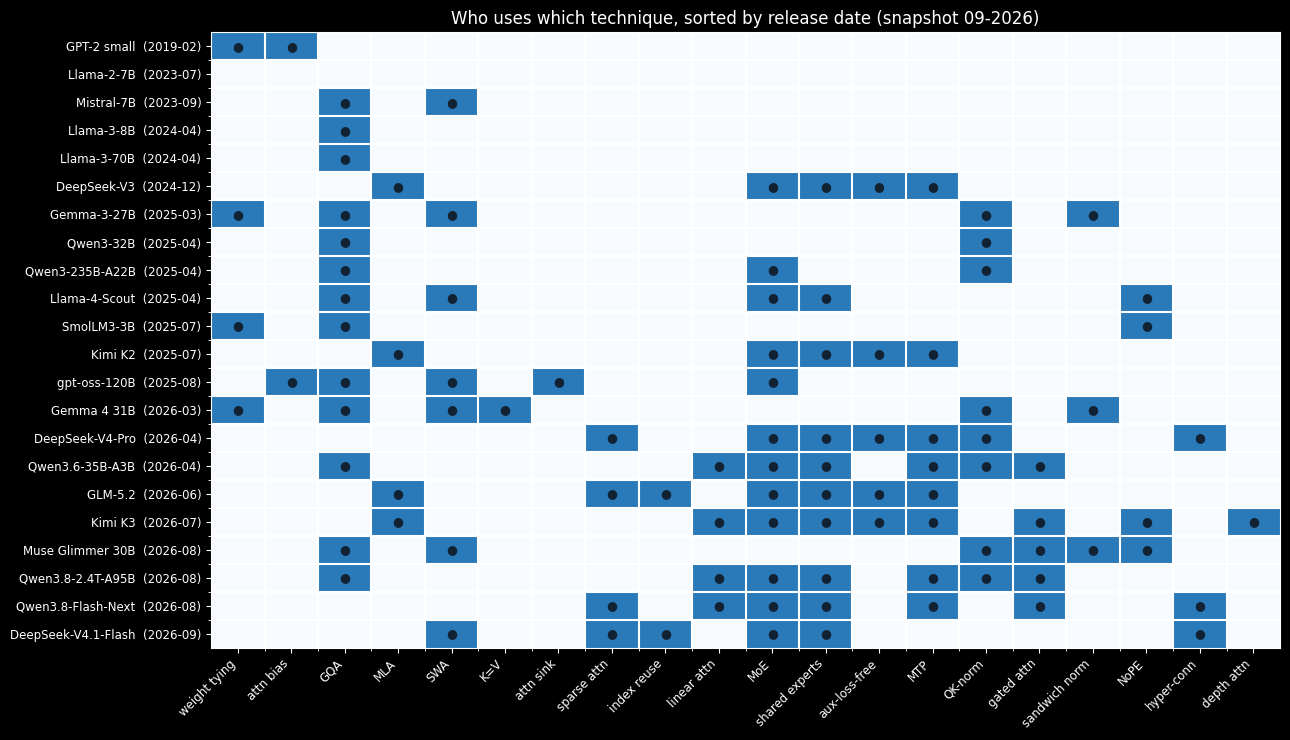

→ out\08_arch_heatmap.png

technique frequency across the showcase:
  GQA              13/22  █████████████
  MoE              12/22  ████████████
  shared experts   10/22  ██████████
  MTP               8/22  ████████
  QK-norm           8/22  ████████
  SWA               7/22  ███████
  aux-loss-free     5/22  █████
  gated attn        5/22  █████
  weight tying      4/22  ████
  MLA               4/22  ████
  sparse attn       4/22  ████
  linear attn       4/22  ████
  NoPE              4/22  ████
  sandwich norm     3/22  ███
  hyper-conn        3/22  ███
  attn bias         2/22  ██
  index reuse       2/22  ██
  K=V               1/22  █
  attn sink         1/22  █
  depth attn        1/22  █


In [44]:
ORDER = ["weight tying", "attn bias", "GQA", "MLA", "SWA", "K=V", "attn sink",
         "sparse attn", "index reuse", "linear attn", "MoE", "shared experts",
         "aux-loss-free", "MTP", "QK-norm", "gated attn", "sandwich norm", "NoPE",
         "hyper-conn", "depth attn"]
assert set(ORDER) == T, f"ORDER and T disagree: {set(ORDER) ^ T}"
for m in MODELS:
    assert m.tricks <= T, f"{m.name} has unknown tricks: {m.tricks - T}"

grid = [[1 if t in m.tricks else 0 for t in ORDER] for m in MODELS]

fig, ax = plt.subplots(figsize=(13, 7.5))
ax.imshow(grid, cmap="Blues", aspect="auto", vmin=0, vmax=1.4)
ax.set_xticks(range(len(ORDER)))
ax.set_xticklabels(ORDER, rotation=45, ha="right", fontsize=8.5)
ax.set_yticks(range(len(MODELS)))
ax.set_yticklabels([f"{m.name}  ({m.date})" for m in MODELS], fontsize=8.5)
for i in range(len(MODELS)):
    for j in range(len(ORDER)):
        if grid[i][j]:
            ax.text(j, i, "●", ha="center", va="center", fontsize=9, color="#123")
ax.set_title("Who uses which technique, sorted by release date (snapshot 09-2026)", fontsize=12)
ax.set_xticks([x - .5 for x in range(1, len(ORDER))], minor=True)
ax.set_yticks([y - .5 for y in range(1, len(MODELS))], minor=True)
ax.grid(which="minor", color="white", lw=1.5)
fig.tight_layout(); fig.savefig(OUT / "08_arch_heatmap.png", dpi=140)
plt.show()
print(f"→ {OUT / '08_arch_heatmap.png'}")

cov = {t: sum(1 for m in MODELS if t in m.tricks) for t in ORDER}
print("\ntechnique frequency across the showcase:")
for t, c in sorted(cov.items(), key=lambda kv: -kv[1]):
    print(f"  {t:<16}{c:>3}/{len(MODELS)}  {'█' * c}")

## 3. The models as points on the axes — one phrase each

In [45]:
print()
for m in MODELS:
    print(f"● {m.name} ({m.date})")
    print(f"    {m.line}")
print("""
Read the list along the axes rather than along the models: what everyone did with the KV
cache, then with the FFN, then with the norm. On each axis the part worth stopping at is who
stepped aside and why — the spread says more than the consensus does.
""")


● GPT-2 small (2019-02)
    the reference point: everything that follows is an edit to this same file
● Llama-2-7B (2023-07)
    the stack has settled: RMSNorm + RoPE + SwiGLU, but the cache is still huge
● Mistral-7B (2023-09)
    the window is on EVERY layer, so the cache stops growing entirely — 512 MiB, forever
● Llama-3-8B (2024-04)
    the consensus configuration; the θ base raised for long context
● Llama-3-70B (2024-04)
    the same stack, just bigger — dense scaling in its purest form
● DeepSeek-V3 (2024-12)
    compress the KV along the FEATURE axis: one 576-value latent instead of K and V
● Gemma-3-27B (2025-03)
    five of every six layers see only 1024 tokens — the window does the compressing
● Qwen3-32B (2025-04)
    the consensus stack + QK-norm; dense and MoE in one family
● Qwen3-235B-A22B (2025-04)
    MoE, no shared expert — a deliberate break with DeepSeek
● Llama-4-Scout (2025-04)
    the Llama line switches to MoE; 8192-token chunks on 3 layers out of 4
● SmolLM3

## 4. The closing thesis — and the numbers that back it

In [46]:
# RMSNorm as the TYPE of norm and a serial block are not columns here: every model in the
# showcase has them, so a column would be a solid stripe carrying no information. Their named
# exceptions live outside this table — Cohere's Command line is still LayerNorm and still runs
# a PARALLEL block, and OLMo 2/3 normalize the OUTPUT of each branch instead of its input.
# "Decoder-only" used to belong in that list and no longer does: DeepSeek-V4.1 splits its forty
# layers into a twenty-layer causal encoder and a twenty-layer decoder. The model is still
# autoregressive — it is not a T5 with cross-attention — but the stack stopped being one
# undivided column, and it now spends 8B parameters on a token it reads against 16B on a token
# it writes. That is the honest form of a consensus claim: state it with its exception.
consensus = [t for t in ORDER if cov[t] >= len(MODELS) * 0.6]
diverged = [t for t in ORDER if 0.15 < cov[t] / len(MODELS) < 0.6]
recent = [m for m in MODELS if m.year >= 2026]
top = max(ORDER, key=lambda t: cov[t])
print(f"Converged (≥60% of the showcase):  "
      f"{', '.join(consensus) or f'nothing — the highest is {top} at {100 * cov[top] / len(MODELS):.0f}%'}")
print(f"Diverged (15-60%):                 {', '.join(diverged)}")

print(f"\nKV cache at {REF_CTX // 1024}k context, across the showcase: "
      f"{min(m.cache_gib for m in MODELS):.2f} to {max(m.cache_gib for m in MODELS):.1f} GiB")
print(f"Compression vs MHA (r): from {max(m.r for m in MODELS):.3f} "
      f"down to {min(m.r for m in MODELS if m.r > 0):.4f} — a factor of "
      f"{max(m.r for m in MODELS) / min(m.r for m in MODELS if m.r > 0):.0f}")
print(f"total/active: from 1.0 (dense) up to "
      f"{max(m.total_b / m.active_b for m in MODELS):.0f} "
      f"({max(MODELS, key=lambda m: m.total_b / m.active_b).name})")

spread = max(m.cache_gib for m in MODELS) / min(m.cache_gib for m in MODELS)
csa = next(m for m in MODELS if m.kv_bits != 16)
print(f"""
The closing thesis.

  Through 2023-2025 the macro-architecture really had converged. Decoder-only, Pre-RMSNorm,
  RoPE, SwiGLU and at least GQA stopped being choices, and that convergence is exactly what
  let us take apart "one model" and count it as having taken apart them all.

  By 2026 that consensus is coming apart at four of its five seams, and the frontier models
  are the ones breaking it:
    • norm PLACEMENT — Gemma normalizes both the input and the output of a branch, OLMo 2
      only the output: h = x + RMSNorm(Attention(x)), with no norm on the input at all. Note
      what did NOT happen: nobody went back to Post-LN. The stream stays an unnormalized sum
      in every row here; what moved is which END of the branch carries the norm. The TYPE of
      norm (RMSNorm) is still unanimous.
    • RoPE — Kimi K3 ships no positional encoding at all. Position is carried by the decay of
      the linear-attention state. Gemma rotates only a quarter of its global-layer dimensions.
    • SwiGLU — K3 replaced it with a soft-capped variant to survive 4-bit training.
    • the SHAPE of the stack — DeepSeek-V4.1 (09-2026) splits its forty layers into a
      twenty-layer causal encoder and a twenty-layer decoder, and spends 8B parameters on a
      token it reads against 16B on a token it writes. Still autoregressive, no cross-attention:
      what broke is not "decoder-only" as a training objective but the assumption that every
      token goes through the same stack.
  What has NOT moved: RMSNorm as the type of norm, and the serial block.

  A counterweight worth stating in the same breath, or the whole showcase reads as
  "progress = new architecture". GLM-5.3 (08-2026) sits on the GLM-5.2 base UNCHANGED — not a
  layer moved — and takes Terminal-Bench 3.0 from 4.6 to 28.3 on post-training alone. It has no
  row here because there is nothing to put in one. The axes below are where architecture moved;
  they are not where all the capability came from.

  And one thing is quietly CONVERGING while the old consensus frays: a sigmoid gate on the
  attention output. Qwen3.6, Qwen3.8, Kimi K3 and Muse Glimmer all ship it, none of the
  pre-2026 rows do. Watch that column — it is what a consensus looks like while it forms,
  as opposed to the solid stripes, which are what one looks like after it has.

  The three divergence axes are now all live, and the third one is new:
    1. attention and KV — GQA → MLA → compression along the SEQUENCE axis (DeepSeek-V4),
       hybrids that keep softmax in one layer of four (Qwen3.6, Qwen3.8, Kimi K3), and
       windows that make the cache stop growing at all (Mistral, Gemma). Spread at 128k:
       {spread:.0f}x — though the bottom of that range is now partly a number format and not a
       shape: V4.1 stores its cache in fp4, which is why its deployed 0.11 GiB sits well below
       what its r of {csa.r:.3f} alone would buy. Two things here go beyond the spread. First, Muse Glimmer reaches
       the SAME r as Kimi K3 (0.010) while staying dense at 30B — 16:1 GQA plus a 3:1 window
       is enough, no MLA and no linear attention required. Cache efficiency is not a
       privilege of the giants. Second, Qwen3.8 went the other way and DOUBLED its KV heads
       (2 → 4) versus Qwen3.6: the first widening in that line. Not every axis moves one way.
    2. FFN sparsity — from dense to 2.8T total on 104B active.
    3. the structure of the residual stream — and this is the one that was theoretical last
       year. DeepSeek-V4 replaces the single additive highway with four streams mixed by a
       doubly stochastic matrix (mHC); Kimi K3 makes each layer READ from the stream through
       a softmax over depth (AttnRes) rather than take the plain sum. The additivity we
       decomposed in the previous section — sublayer contributions that sum back to the
       model's own logit — is a property of the architecture we studied, and not a law of
       nature. In K3 it holds only inside a 12-layer block.

  These three axes are what open the remaining 13 lectures: why this data (L3), how to train
  it at all (L4), how to align it (L5-7), how to measure it (L8), production (L9-12).
""")

Converged (≥60% of the showcase):  nothing — the highest is GQA at 59%
Diverged (15-60%):                 weight tying, GQA, MLA, SWA, sparse attn, linear attn, MoE, shared experts, aux-loss-free, MTP, QK-norm, gated attn, NoPE

KV cache at 128k context, across the showcase: 0.11 to 64.0 GiB
Compression vs MHA (r): from 1.000 down to 0.0039 — a factor of 255
total/active: from 1.0 (dense) up to 34 (DeepSeek-V4.1-Flash)

The closing thesis.

  Through 2023-2025 the macro-architecture really had converged. Decoder-only, Pre-RMSNorm,
  RoPE, SwiGLU and at least GQA stopped being choices, and that convergence is exactly what
  let us take apart "one model" and count it as having taken apart them all.

  By 2026 that consensus is coming apart at four of its five seams, and the frontier models
  are the ones breaking it:
    • norm PLACEMENT — Gemma normalizes both the input and the output of a branch, OLMo 2
      only the output: h = x + RMSNorm(Attention(x)), with no norm on the input at 

## What to add on top (ready-made diagrams, so you do not have to draw them)

* Sebastian Raschka, **The Big LLM Architecture Comparison** —
  https://magazine.sebastianraschka.com/p/the-big-llm-architecture-comparison
  and **LLM Architecture Gallery** — https://sebastianraschka.com/llm-architecture-gallery/
  Ready block diagrams of every model in our table, in one style and one scale.
* **Recent Developments: KV Sharing, mHC, Compressed Attention** —
  https://magazine.sebastianraschka.com/p/recent-developments-in-llm-architectures
* Stanford CS336, lecture 3 "Architectures, hyperparameters" —
  https://github.com/stanford-cs336/lectures — a complementary table for DENSE models,
  with the hyperparameters we deliberately skip (d_ff/d_model, aspect ratio, vocabulary).
  Their `Pre-norm` column is where the norm-placement counter-examples above come from.
* Tech reports worth keeping open: DeepSeek-V4
  ([2606.19348](https://arxiv.org/abs/2606.19348)), Kimi K3
  ([2607.24653](https://arxiv.org/abs/2607.24653)), Gemma 4
  ([2607.02770](https://arxiv.org/abs/2607.02770)), GLM-5
  ([2602.15763](https://arxiv.org/abs/2602.15763)), and for the residual-stream axis
  Hyper-Connections ([2409.19606](https://arxiv.org/abs/2409.19606)) and
  Attention Residuals ([2603.15031](https://arxiv.org/abs/2603.15031)).